<a href="https://colab.research.google.com/github/xhsjs6231-boop/Final-Team1/blob/main/TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#한글 글씨 폰트 설치
%%capture
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

In [22]:
import pandas as pd  #데이터 분석 라이브러리
import matplotlib.pyplot as plt # 시각화 도구 라이브러리

In [23]:
path = '/content/weighted_score_above_08.csv'

df = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="skip"   # skip malformed rows
)



#얼리엑세스 무의미

In [30]:
# df 또는 df_use 어디에서든, 모델/전처리 직전에 1줄 추가
if '*author_playtime_forever' in df.columns and 'author_playtime_forever' in df.columns:
    # 이미 정리된 상태면 아래 줄은 필요 없습니다.
    pass
elif 'author_playtime_forever' in df.columns:
    df['*author_playtime_forever'] = df['author_playtime_forever']


In [31]:
df = df[(df["author_num_games_owned"] != 0) &
        (df["*author_playtime_forever"] != 0) ]

In [32]:
df = df.drop(columns=["review"])

In [33]:
df = df[~((df["author_num_games_owned"] == 0) & (df["author_playtime_at_review"] == 0))]


In [ ]:
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon
import numpy as np

# df: 원본 리뷰 단위 데이터
# 필요한 컬럼: appid, written_during_early_access(0/1), voted_up(0/1)

# 1) appid x EA여부별 긍정률/표본수
g = df.groupby(['appid', 'written_during_early_access'])['voted_up']
agg = g.agg(PosRate='mean', N='size').reset_index()

# 2) wide로 피벗 (0=Post, 1=EA)
wide = agg.pivot(index='appid',
                 columns='written_during_early_access',
                 values='PosRate')

# 컬럼명 정리
wide.columns = ['Post_PosRate', 'EA_PosRate']  # 0 -> Post, 1 -> EA

# 3) EA와 Post가 모두 있는 appid만 사용
paired = wide.dropna().copy()

# (선택) 너무 표본수가 작은 게임 제거 기준 예: EA/Post 각각 리뷰 N>=30 이상만
cnt = agg.pivot(index='appid', columns='written_during_early_access', values='N')
cnt.columns = ['Post_N', 'EA_N']
paired = paired.join(cnt, how='left')
paired = paired[(paired['EA_N'] >= 30) & (paired['Post_N'] >= 30)]

print(f"쌍의 개수(게임 수): {len(paired)}")
print(paired.head())

# 4) 대응표본 t-검정
t_stat, p_val = ttest_rel(paired['EA_PosRate'], paired['Post_PosRate'], nan_policy='omit')
print(f"[Paired t-test] t={t_stat:.4f}, p={p_val:.3e}")

# 5) 비모수 대안: Wilcoxon signed-rank
w_stat, w_p = wilcoxon(paired['EA_PosRate'], paired['Post_PosRate'], zero_method='wilcox', alternative='two-sided')
print(f"[Wilcoxon] W={w_stat:.4f}, p={w_p:.3e}")

# 6) 효과크기 (paired Cohen's d; dz = mean(diff)/sd(diff))
diff = paired['Post_PosRate'] - paired['EA_PosRate']
dz = diff.mean() / diff.std(ddof=1)
print(f"[Effect size] Cohen's dz = {dz:.3f}, mean diff = {diff.mean():.4f}")


쌍의 개수(게임 수): 78
        Post_PosRate  EA_PosRate  Post_N   EA_N
appid                                          
220200      0.938697    1.000000   261.0   30.0
221100      0.787521    0.488971   593.0  272.0
242760      0.991371    0.990000  1043.0  200.0
244850      0.777778    0.958333    72.0   72.0
246620      0.996622    1.000000   296.0   30.0
[Paired t-test] t=2.5638, p=1.230e-02
[Wilcoxon] W=475.0000, p=1.578e-04
[Effect size] Cohen's dz = -0.290, mean diff = -0.0269


# EA보다 정식 출시 후 긍정률이 더 높은 게임만 필터링

In [ ]:
# 7. EA < 출시후 조건 (2번째 경우만)
improved_games = pos_rate[pos_rate["EA_PosRate"] < pos_rate["Post_PosRate"]]

print(improved_games.to_string(index=False))


 Post_PosRate  EA_PosRate
      0.87398    0.863986


In [ ]:
from scipy import stats

# EA < 출시후 조건 (2번째 경우만)
improved_games = pos_rate[pos_rate["EA_PosRate"] < pos_rate["Post_PosRate"]]

# 대응표본 t-test
t_stat, p_value = stats.ttest_rel(
    improved_games["EA_PosRate"],
    improved_games["Post_PosRate"]
)

print("t-statistic:", t_stat)
print("p-value:", p_value)



t-statistic: nan
p-value: nan


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


#지역별

In [ ]:
import pandas as pd

# 1. 무료 제공 제외 (실제 구매만 분석할 경우)
df_paid = df[df["received_for_free"] == False]

# 2. 지역(언어권)별 집계
region_stats = df_paid.groupby("language").agg(
    PosRate=("voted_up", "mean"),
    ReviewCount=("voted_up", "count"),
    AvgPlaytime=("author_playtime_forever", "mean"),
    MedianPlaytime=("author_playtime_forever", "median"),
    PurchaseRate=("steam_purchase", "mean")
).reset_index()

# 3. 리뷰 카운트 100 이상만 필터링
region_stats = region_stats[region_stats["ReviewCount"] >= 100]

# 4. 긍정률 높은 순으로 정렬
region_stats = region_stats.sort_values(by="PosRate", ascending=False)

print(region_stats.head(10))


In [ ]:
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. 상관분석
corr_play, p_play = stats.pearsonr(region_stats["PosRate"], region_stats["AvgPlaytime"])
corr_purchase, p_purchase = stats.pearsonr(region_stats["PosRate"], region_stats["PurchaseRate"])

print(f"PosRate vs AvgPlaytime: r={corr_play:.3f}, p={p_play:.3f}")
print(f"PosRate vs PurchaseRate: r={corr_purchase:.3f}, p={p_purchase:.3f}")

# 2. 회귀분석 (구매율 ~ 긍정률)
X = sm.add_constant(region_stats["PosRate"])
y = region_stats["PurchaseRate"]
model = sm.OLS(y, X).fit()
print(model.summary())

# 3. 시각화 (긍정률 vs 플레이타임)
plt.scatter(region_stats["PosRate"], region_stats["AvgPlaytime"])
plt.xlabel("Positive Rate")
plt.ylabel("Average Playtime")
plt.title("Positive Rate vs Average Playtime")
plt.show()


#2. 소비자 유형별 평가 차이
author_num_games_owned, author_num_reviews → 코어 게이머 vs 라이트 유저 분류 가설: 보유 게임 수가 많은 게이머는 더 까다롭게 평가, 리뷰 수가 많은 유저는 극단적 의견 경

In [36]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# -----------------------------
# 0) dtype 다운캐스팅 & 전처리
# -----------------------------
cols = [
    'recommendationid','appid','game','author_steamid',
    'author_num_games_owned','author_num_reviews',
    'author_playtime_forever','author_playtime_at_review',
    'language','timestamp_created','voted_up','steam_purchase',
    'received_for_free','written_during_early_access',
    'hidden_in_steam_china','steam_china_location'
]
df_use = df[cols].copy()

# dtypes
for c in ['recommendationid','appid','author_steamid']:
    if c in df_use:
        df_use[c] = pd.to_numeric(df_use[c], errors='coerce', downcast='integer')
for c in ['author_num_games_owned','author_num_reviews']:
    if c in df_use:
        df_use[c] = pd.to_numeric(df_use[c], errors='coerce', downcast='integer')
for c in ['author_playtime_forever','author_playtime_at_review']:
    if c in df_use:
        df_use[c] = pd.to_numeric(df_use[c], errors='coerce', downcast='float')

bin_cols = ['voted_up','steam_purchase','received_for_free','written_during_early_access']
for c in bin_cols:
    if c in df_use:
        df_use[c] = pd.to_numeric(df_use[c], errors='coerce').fillna(0).astype('int8')

# 범주형 (메모리 크게 절약)
for c in ['language','game','steam_china_location']:
    if c in df_use:
        df_use[c] = df_use[c].astype('category')

# 결측 제거(핵심만)
df_use = df_use.dropna(subset=['author_num_games_owned','author_num_reviews','voted_up'])

# 윈저라이즈(상하위 1%)
for c in ['author_num_games_owned','author_num_reviews','author_playtime_forever','author_playtime_at_review']:
    if c in df_use:
        lo, hi = df_use[c].quantile([0.01, 0.99])
        df_use[c] = df_use[c].clip(lo, hi)

# -----------------------------
# 1) 코어/라이트 & 리뷰어 구간 라벨 (벡터화)
# -----------------------------
q25_games = df_use['author_num_games_owned'].quantile(0.25)
q75_games = df_use['author_num_games_owned'].quantile(0.75)
q25_revs  = df_use['author_num_reviews'].quantile(0.25)
q75_revs  = df_use['author_num_reviews'].quantile(0.75)

core_gamer   = (df_use['author_num_games_owned'] >= q75_games).astype('int8')
light_user   = (df_use['author_num_games_owned'] <= q25_games).astype('int8')
heavy_rev    = (df_use['author_num_reviews'] >= q75_revs).astype('int8')
light_rev    = (df_use['author_num_reviews'] <= q25_revs).astype('int8')

df_use['core_gamer']      = core_gamer
df_use['heavy_reviewer']  = heavy_rev

df_use['segment'] = pd.Categorical(
    np.select(
        [
            (core_gamer.eq(1) & heavy_rev.eq(1)),
            (core_gamer.eq(1) & light_rev.eq(1)),
            (light_user.eq(1) & heavy_rev.eq(1)),
            (light_user.eq(1) & light_rev.eq(1)),
        ],
        ['Core × Heavy','Core × Light','Light × Heavy','Light × Light'],
        default='Middle'
    )
)


# -----------------------------
# 2) 그룹 통계 (가벼운 출력만)
# -----------------------------
grp = df_use.groupby('segment', observed=True)['voted_up']
summary = pd.DataFrame({
    'n': grp.size(),
    'pos_rate': grp.mean(),
})
summary['se'] = np.sqrt(summary['pos_rate']*(1-summary['pos_rate'])/summary['n'].clip(lower=1))
summary['ci_low'] = summary['pos_rate'] - 1.96*summary['se']
summary['ci_high'] = summary['pos_rate'] + 1.96*summary['se']
print("\n[그룹별 긍정률/CI]")
print(summary.sort_index())

# -----------------------------
# 3) 두 비율 z-검정 (코어 vs 라이트 극단)
# -----------------------------
extreme = df_use[(core_gamer==1) | (light_user==1)]
core = extreme[core_gamer.loc[extreme.index]==1]['voted_up'].astype('int8')
light = extreme[core_gamer.loc[extreme.index]==0]['voted_up'].astype('int8')

def prop_ztest(success_a, size_a, success_b, size_b):
    p_pool = (success_a + success_b) / (size_a + size_b)
    se = np.sqrt(p_pool*(1-p_pool)*(1/size_a + 1/size_b))
    z = (success_a/size_a - success_b/size_b) / se
    p = 2*(1 - stats.norm.cdf(abs(z)))
    return z, p

z, p = prop_ztest(core.sum(), core.size, light.sum(), light.size)
print(f"\n[비율 z-test] 코어 vs 라이트: z={z:.3f}, p={p:.5f}")

# -----------------------------
# 4) 로지스틱: GEE Binomial (게임 그룹화)
# -----------------------------
# 상위 K개 언어만 유지, 나머지는 'Other'
K = 10
top_lang = df_use['language'].value_counts().head(K).index

# 1) pandas where 사용 (np.where 아님)  → dtype 안전
df_use['lang_top'] = df_use['language'].astype('string').where(
    df_use['language'].isin(top_lang),
    other='Other'
)

# 2) 카테고리로 변환 (명시적 카테고리 세트 지정)
cats = list(top_lang.astype('string')) + ['Other']
df_use['lang_top'] = pd.Categorical(df_use['lang_top'], categories=cats, ordered=False)

# 3) GEE 포뮬러 (그대로 사용 가능)
gee_formula = (
    "voted_up ~ core_gamer + heavy_reviewer + core_gamer:heavy_reviewer"
    " + author_playtime_at_review + received_for_free + steam_purchase"
    " + written_during_early_access + C(lang_top)"
)

# GEE: 게임별 상관(교환가능 구조)
fam = sm.families.Binomial()
ind = sm.cov_struct.Exchangeable()

gee_model = smf.gee(gee_formula, groups="appid", data=df_use, family=fam, cov_struct=ind)
gee_res = gee_model.fit()
print("\n[GEE 결과 요약]")
print(gee_res.summary())

# 오즈비 표
par = gee_res.params
conf = gee_res.conf_int()
or_tab = pd.DataFrame({
    'OR': np.exp(par),
    'CI_low': np.exp(conf[0]),
    'CI_high': np.exp(conf[1]),
    'pvalue': gee_res.pvalues
}).sort_values('pvalue')
print("\n[중요 계수 OR표 (상위 20)]")
print(or_tab.head(20))

# -----------------------------
# 5) 간단 성능(의사확률)
# -----------------------------
pred_prob = gee_res.predict(df_use)  # GEE도 확률 제공
from sklearn.metrics import roc_auc_score, brier_score_loss
auc = roc_auc_score(df_use['voted_up'].astype(int), pred_prob)
brier = brier_score_loss(df_use['voted_up'].astype(int), pred_prob)
print(f"\n[모델 성능] AUC={auc:.3f}, Brier={brier:.4f}")

# 캘리브레이션(10분위) - 메모리 가볍게
p = pd.Series(pred_prob, index=df_use.index)
rank = p.rank(method='first')
decile = ((rank - 1) / max(1, len(p)) * 10).astype(int).clip(0,9)
cal = pd.DataFrame({'y': df_use['voted_up'].astype(int), 'p': p, 'decile': decile})
cal_out = cal.groupby('decile', observed=True).agg(mean_p=('p','mean'), obs_rate=('y','mean'), n=('y','size'))
print("\n[캘리브레이션: 예측확률 vs 실측율(10분위)]")
print(cal_out)



[그룹별 긍정률/CI]
                    n  pos_rate        se    ci_low   ci_high
segment                                                      
Core × Heavy    44474  0.872982  0.001579  0.869887  0.876077
Core × Light     3531  0.832625  0.006282  0.820312  0.844939
Light × Heavy    1080  0.923148  0.008105  0.907262  0.939034
Light × Light   43458  0.867274  0.001628  0.864084  0.870464
Middle         197021  0.874460  0.000746  0.872997  0.875923

[비율 z-test] 코어 vs 라이트: z=-11.954, p=0.00000

[GEE 결과 요약]
                               GEE Regression Results                              
Dep. Variable:                    voted_up   No. Observations:               289564
Model:                                 GEE   No. clusters:                    18461
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                2167
Family:                           Binomial   Mean cluster size:           

In [37]:
# -*- coding: utf-8 -*-
import numpy as np, pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, brier_score_loss

# ===== 파라미터 =====
clip_pct = 0.05          # 극단값 완화: 상하위 5%
top_k_lang = 5           # 언어 상위 K만 더미화, 나머지 Other
subsample_n = None       # e.g., 200_000 (메모리 압박 심할 때만)

# ===== 입력 =====
cols = [
    'game','author_steamid','language','voted_up',
    'author_num_games_owned','author_num_reviews',
    'author_playtime_at_review','received_for_free',
    'steam_purchase','written_during_early_access'
]
df_use = df[cols].dropna().copy()

# 타입/바이너리 정리
df_use['voted_up'] = df_use['voted_up'].astype(int)
for c in ['received_for_free','steam_purchase','written_during_early_access']:
    if c in df_use: df_use[c] = df_use[c].astype(int)

# 극단값 완화 (상하위 clip_pct)
for c in ['author_num_games_owned','author_num_reviews','author_playtime_at_review']:
    lo, hi = df_use[c].quantile([clip_pct, 1-clip_pct])
    df_use[c] = df_use[c].clip(lo, hi)

# 코어/헤비 라벨 (상위 사분위)
q75_games = df_use['author_num_games_owned'].quantile(0.75)
q75_revs  = df_use['author_num_reviews'].quantile(0.75)
df_use['core_gamer']     = (df_use['author_num_games_owned'] >= q75_games).astype(int)
df_use['heavy_reviewer'] = (df_use['author_num_reviews']   >= q75_revs ).astype(int)

# 언어 상위 K만 유지
top_lang = df_use['language'].value_counts().head(top_k_lang).index
df_use['lang_top'] = np.where(df_use['language'].isin(top_lang), df_use['language'], 'Other')

# 메모리 절감: 필요한 열만, 다운캐스트
df_use = df_use[['voted_up','core_gamer','heavy_reviewer','author_playtime_at_review',
                 'received_for_free','steam_purchase','written_during_early_access','lang_top']].copy()
for c in ['core_gamer','heavy_reviewer','received_for_free','steam_purchase','written_during_early_access']:
    df_use[c] = df_use[c].astype('int8')
df_use['author_playtime_at_review'] = pd.to_numeric(df_use['author_playtime_at_review'], downcast='float')
df_use['lang_top'] = df_use['lang_top'].astype('category')

# (선택) 다운샘플링(라벨 보존)
if subsample_n is not None and len(df_use) > subsample_n:
    df_pos = df_use[df_use['voted_up']==1].sample(subsample_n//2, random_state=42, replace=False)
    df_neg = df_use[df_use['voted_up']==0].sample(subsample_n - len(df_pos), random_state=42, replace=False)
    df_use = pd.concat([df_pos, df_neg], axis=0).sample(frac=1.0, random_state=42)

# 로지스틱 (게임 FE 제거 → 빠름)
formula = (
    "voted_up ~ core_gamer + heavy_reviewer + core_gamer:heavy_reviewer"
    " + author_playtime_at_review + received_for_free + steam_purchase"
    " + written_during_early_access + C(lang_top)"
)
model = smf.logit(formula=formula, data=df_use).fit(disp=False)
res = model  # 강건SE 없이도 경량화; 필요 시 get_robustcov_results 사용

# 성능/보정
pred = res.predict()
auc = roc_auc_score(df_use['voted_up'], pred)
brier = brier_score_loss(df_use['voted_up'], pred)

# OR 테이블
params = res.params; conf = res.conf_int()
or_table = pd.DataFrame({
    'OR': np.exp(params),
    'CI_low': np.exp(conf[0]),
    'CI_high': np.exp(conf[1]),
    'pvalue': res.pvalues
}).sort_values('pvalue')

print("\n[요약]")
print(res.summary())
print("\n[AUC, Brier]", round(auc,3), round(brier,4))
print("\n[OR 상위 15]")
print(or_table.head(15))



[요약]
                           Logit Regression Results                           
Dep. Variable:               voted_up   No. Observations:               289549
Model:                          Logit   Df Residuals:                   289536
Method:                           MLE   Df Model:                           12
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                 0.01046
Time:                        07:41:30   Log-Likelihood:            -1.0915e+05
converged:                       True   LL-Null:                   -1.1030e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.8488      0.020     93.193      0.000       1.810       1.888
C(lang_top)[T.brazilian]       -0.0618      0.036     -1.721      0.085   

#3. 구매 여부와 평가 태도
steam_purchase, received_for_free → 구매/무료 배포 여부에 따른 긍정률 차이 가설: 무료로 받은 유저는 호의적이거나(“공짜니까 좋다”), 또는 부정적(“돈 내고 살 가치는 없다”) 양극화 가능

In [38]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 필요한 컬럼만
cols = [
    'voted_up','steam_purchase','received_for_free',
    'author_playtime_at_review','author_num_games_owned','author_num_reviews',
    'language','written_during_early_access'
]
dfu = df[cols].copy()

# 유효값만 (라벨/핵심변수 결측 제거)
dfu = dfu.dropna(subset=['voted_up','steam_purchase','received_for_free']).copy()

# 타입 정리
dfu['voted_up'] = dfu['voted_up'].astype(int)
dfu['steam_purchase'] = dfu['steam_purchase'].astype(int)
dfu['received_for_free'] = dfu['received_for_free'].astype(int)

# 선택: 극단치 완화(플레이시간 로그 + 상한 Winsorize 99%)
if 'author_playtime_at_review' in dfu:
    p99 = dfu['author_playtime_at_review'].quantile(0.99)
    dfu['playtime_capped'] = np.minimum(dfu['author_playtime_at_review'], p99)
    dfu['log_playtime'] = np.log1p(dfu['playtime_capped'])
else:
    dfu['log_playtime'] = 0.0

# 언어 Top-k만 더미화(희소성/메모리 절약)
k = 10
top_langs = dfu['language'].value_counts().nlargest(k).index
dfu['lang_top'] = np.where(dfu['language'].isin(top_langs), dfu['language'], 'OTHER')


In [39]:
# (A) 각 단일 변수 기준
tab_purchase = dfu.groupby('steam_purchase')['voted_up'].agg(['mean','count']).rename(columns={'mean':'PosRate','count':'N'})
tab_free = dfu.groupby('received_for_free')['voted_up'].agg(['mean','count']).rename(columns={'mean':'PosRate','count':'N'})

# (B) 교차조건(유료/무료 조합)
tab_cross = (dfu
    .groupby(['steam_purchase','received_for_free'])['voted_up']
    .agg(['mean','count'])
    .rename(columns={'mean':'PosRate','count':'N'})
    .reset_index()
)

print("== steam_purchase by PosRate ==")
print(tab_purchase.round(4))
print("\n== received_for_free by PosRate ==")
print(tab_free.round(4))
print("\n== Cross (steam_purchase x received_for_free) ==")
print(tab_cross.round(4))


== steam_purchase by PosRate ==
                PosRate       N
steam_purchase                 
0                0.8461   96625
1                0.8862  192939

== received_for_free by PosRate ==
                   PosRate       N
received_for_free                 
0                   0.8724  278600
1                   0.8843   10964

== Cross (steam_purchase x received_for_free) ==
   steam_purchase  received_for_free  PosRate       N
0               0                  0   0.8430   87437
1               0                  1   0.8760    9188
2               1                  0   0.8858  191163
3               1                  1   0.9268    1776


In [40]:
def chisq_and_cramers_v(df_sub, col):
    ct = pd.crosstab(df_sub[col], df_sub['voted_up'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    # Cramér's V
    phi2 = chi2 / n
    r, c = ct.shape
    v = np.sqrt(phi2 / (min(r-1, c-1)))
    return ct, chi2, dof, p, v

for col in ['steam_purchase','received_for_free']:
    ct, chi2, dof, p, v = chisq_and_cramers_v(dfu, col)
    print(f"\n== Chi-square for {col} ==")
    print(ct)
    print(f"chi2={chi2:.3f}, dof={dof}, p={p:.4g}, CramersV={v:.3f}")



== Chi-square for steam_purchase ==
voted_up            0       1
steam_purchase               
0               14870   81755
1               21955  170984
chi2=932.377, dof=1, p=8.986e-205, CramersV=0.057

== Chi-square for received_for_free ==
voted_up               0       1
received_for_free               
0                  35556  243044
1                   1269    9695
chi2=13.309, dof=1, p=0.0002641, CramersV=0.007


In [41]:
from math import sqrt

def two_prop_ztest(success1, n1, success2, n2):
    p1 = success1 / n1
    p2 = success2 / n2
    p_pool = (success1 + success2) / (n1 + n2)
    se = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    z = (p1 - p2) / se
    p = 2*(1 - stats.norm.cdf(abs(z)))
    return p1, p2, z, p

def wilson_ci(success, n, alpha=0.05):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = success / n
    z = stats.norm.ppf(1 - alpha/2)
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    half = (z*np.sqrt((p*(1-p)/n) + z**2/(4*n**2))) / denom
    return p, (center - half), (center + half)

# (A) steam_purchase: 1 vs 0
g1 = dfu[dfu['steam_purchase']==1]['voted_up']
g0 = dfu[dfu['steam_purchase']==0]['voted_up']
p1, p0, z, p = two_prop_ztest(g1.sum(), g1.size, g0.sum(), g0.size)
print("\n== Two-proportion z-test: steam_purchase (1 vs 0) ==")
print(f"PosRate(1)={p1:.4f}, PosRate(0)={p0:.4f}, z={z:.3f}, p={p:.4g}")
print("Wilson 95% CI:")
print("  1:", wilson_ci(g1.sum(), g1.size))
print("  0:", wilson_ci(g0.sum(), g0.size))

# (B) received_for_free: 1 vs 0
g1 = dfu[dfu['received_for_free']==1]['voted_up']
g0 = dfu[dfu['received_for_free']==0]['voted_up']
p1, p0, z, p = two_prop_ztest(g1.sum(), g1.size, g0.sum(), g0.size)
print("\n== Two-proportion z-test: received_for_free (1 vs 0) ==")
print(f"PosRate(1)={p1:.4f}, PosRate(0)={p0:.4f}, z={z:.3f}, p={p:.4g}")
print("Wilson 95% CI:")
print("  1:", wilson_ci(g1.sum(), g1.size))
print("  0:", wilson_ci(g0.sum(), g0.size))



== Two-proportion z-test: steam_purchase (1 vs 0) ==
PosRate(1)=0.8862, PosRate(0)=0.8461, z=30.541, p=0
Wilson 95% CI:
  1: (np.float64(0.8862075578291584), np.float64(0.8847828856843079), np.float64(0.8876168513217777))
  0: (np.float64(0.8461060802069857), np.float64(0.8438170883213459), np.float64(0.8483675533469873))

== Two-proportion z-test: received_for_free (1 vs 0) ==
PosRate(1)=0.8843, PosRate(0)=0.8724, z=3.663, p=0.0002495
Wilson 95% CI:
  1: (np.float64(0.8842575702298431), np.float64(0.878134280316397), np.float64(0.890111689652793))
  0: (np.float64(0.8723761665470208), np.float64(0.8711320185744479), np.float64(0.8736100456898309))


In [42]:
# 기본 모형: 구매/무료 여부만
m0 = smf.logit("voted_up ~ steam_purchase + received_for_free", data=dfu).fit(disp=False)
print("\n== Logit m0 ==")
print(m0.summary())

# 오즈비(OR)와 95% CI
or_m0 = np.exp(m0.params)
ci_m0 = np.exp(m0.conf_int())
print("\nOR (95% CI) - m0")
print(pd.concat([or_m0.rename('OR'), ci_m0.rename(columns={0:'LCI',1:'UCI'})], axis=1))

# 통제변수 추가 (행동/숙련 대리변수 + 언어 + EA여부)
dfu['ea'] = dfu['written_during_early_access'].fillna(0).astype(int)
dfu['log_reviews'] = np.log1p(dfu['author_num_reviews'].fillna(0))
dfu['log_owned'] = np.log1p(dfu['author_num_games_owned'].fillna(0))

# 언어 더미(Top-k + OTHER 기준)
lang_dummies = pd.get_dummies(dfu['lang_top'], prefix='lang', drop_first=True)
X = pd.concat([
    pd.DataFrame({
        'steam_purchase': dfu['steam_purchase'],
        'received_for_free': dfu['received_for_free'],
        'log_playtime': dfu['log_playtime'],
        'log_reviews': dfu['log_reviews'],
        'log_owned': dfu['log_owned'],
        'ea': dfu['ea'],
    }),
    lang_dummies
], axis=1)
X = sm.add_constant(X, has_constant='add')
y = dfu['voted_up']

m1 = sm.Logit(y, X).fit(disp=False)
print("\n== Logit m1 (controls) ==")
print(m1.summary())

# OR와 CI
or_m1 = np.exp(m1.params)
ci_m1 = np.exp(m1.conf_int())
print("\nOR (95% CI) - m1")
print(pd.concat([or_m1.rename('OR'), ci_m1.rename(columns={0:'LCI',1:'UCI'})], axis=1))

# 상호작용(양극화 가설 점검): 구매*무료
m2 = smf.logit("voted_up ~ steam_purchase * received_for_free + log_playtime + log_reviews + log_owned + ea + C(lang_top)", data=dfu).fit(disp=False)
print("\n== Logit m2 (interaction) ==")
print(m2.summary())
print("\nOR (95% CI) - m2 (주요항)")
or_m2 = np.exp(m2.params[['steam_purchase','received_for_free','steam_purchase:received_for_free']])
ci_m2 = np.exp(m2.conf_int().loc[['steam_purchase','received_for_free','steam_purchase:received_for_free']])
print(pd.concat([or_m2.rename('OR'), ci_m2.rename(columns={0:'LCI',1:'UCI'})], axis=1))



== Logit m0 ==
                           Logit Regression Results                           
Dep. Variable:               voted_up   No. Observations:               289564
Model:                          Logit   Df Residuals:                   289561
Method:                           MLE   Df Model:                            2
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                0.004580
Time:                        07:45:27   Log-Likelihood:            -1.0981e+05
converged:                       True   LL-Null:                   -1.1032e+05
Covariance Type:            nonrobust   LLR p-value:                3.922e-220
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.6783      0.009    181.646      0.000       1.660       1.696
steam_purchase        0.3718      0.012     31.911      0.000       0.349       0.395
received

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
# (A) 성향점수: "무료 수령 여부"를 종속변수로 예측
ps_formula = "received_for_free ~ log_playtime + log_reviews + log_owned + ea + C(lang_top)"
ps_mod = smf.logit(ps_formula, data=dfu).fit(disp=False)
dfu['ps'] = ps_mod.predict(dfu)

# 안정화된 IPW (stabilized weights)
p_treat = dfu['received_for_free'].mean()
dfu['sw'] = np.where(dfu['received_for_free']==1, p_treat/dfu['ps'], (1-p_treat)/(1-dfu['ps']))

# (B) 가중 로짓: 무료 효과의 강건성
ipw_mod = smf.glm(
    formula="voted_up ~ received_for_free + steam_purchase + log_playtime + log_reviews + log_owned + ea + C(lang_top)",
    data=dfu,
    family=sm.families.Binomial(),
    freq_weights=dfu['sw']
).fit()

print("\n== IPW-GLM (Binomial) ==")
print(ipw_mod.summary())

# OR와 CI
params = ipw_mod.params
cov = ipw_mod.cov_params()
se = np.sqrt(np.diag(cov))
z = stats.norm.ppf(0.975)
or_ipw = np.exp(params)
lci = np.exp(params - z*se)
uci = np.exp(params + z*se)
or_table = pd.DataFrame({'OR':or_ipw, 'LCI':lci, 'UCI':uci})
print("\nOR (95% CI) - IPW")
print(or_table.loc[['received_for_free','steam_purchase']])


In [ ]:
def binvar_polarization(y):
    p = y.mean()
    var = p*(1-p)
    # 이진 엔트로피 (log2)
    eps = 1e-12
    ent = -(p*np.log2(p+eps) + (1-p)*np.log2(1-p+eps))
    return p, var, ent

for col in ['steam_purchase','received_for_free']:
    print(f"\n== Polarization metrics by {col} ==")
    for v in [0,1]:
        y = dfu.loc[dfu[col]==v, 'voted_up']
        p,var,ent = binvar_polarization(y)
        print(f"{col}={v}: PosRate={p:.4f}, Var={var:.4f}, Entropy={ent:.4f}")


#4. 언어/지역 기반 태도 차이
 language, steam_china_location, hidden_in_steam_china → 지역별 긍정률, 검열 영향 분석 가설: 특정 지역(중국/비중국)에서 평점 패턴이 다르게 나타남
 #중단


In [ ]:
import pandas as pd

# 지역(중국/비중국) 변수 생성
df["is_china"] = df["steam_china_location"].fillna(0).astype(int)

# 그룹별 긍정률 요약
region_stats = df.groupby("is_china")["voted_up"].agg(["mean", "count"])
lang_stats = df.groupby("language")["voted_up"].agg(["mean", "count"]).sort_values("count", ascending=False).head(10)

print("== 지역별 긍정률 ==")
print(region_stats)
print("\n== 상위 10개 언어별 긍정률 ==")
print(lang_stats)


In [ ]:
import numpy as np
import pandas as pd

def prep_base(df):
    use = df[["voted_up","steam_china_location","hidden_in_steam_china","language"]].copy()

    # voted_up → 0/1 정수
    use["voted_up"] = use["voted_up"].astype("float").round().astype("Int64")

    # is_china 파생 (NaN→0)
    use["is_china"] = use["steam_china_location"].fillna(0).astype("Int64")

    # hidden_in_steam_china → 0/1 (문자/불리언 혼재 대비)
    use["hidden_in_steam_china"] = (
        use["hidden_in_steam_china"]
        .replace({True:1, False:0, "True":1, "False":0})
        .fillna(0)
        .astype("Int64")
    )

    # 무의미 공백/NaN 언어 → 'unknown'
    use["language"] = use["language"].astype(str).str.strip().replace({"": np.nan}).fillna("unknown")

    # Inf → NaN, 그리고 결측 제거
    use = use.replace([np.inf, -np.inf], np.nan).dropna(subset=["voted_up","is_china","hidden_in_steam_china","language"])

    # 정수→일반 int (statsmodels에서 Nullable Int64 보다 안전)
    use[["voted_up","is_china","hidden_in_steam_china"]] = use[["voted_up","is_china","hidden_in_steam_china"]].astype(int)

    return use

use = prep_base(df)
use.head()


In [ ]:
from scipy.stats import chi2_contingency

# 요약
region_stats = use.groupby("is_china")["voted_up"].agg(PosRate="mean", N="count")
print("== 지역별 긍정률 ==")
print(region_stats)

# 카이제곱
ct = pd.crosstab(use["is_china"], use["voted_up"])
chi2, p, dof, expected = chi2_contingency(ct)
print("\n[Chi-square]")
print(f"chi2={chi2:.3f}, dof={dof}, p={p:.6f}")


In [ ]:
import numpy as np, pandas as pd
from scipy.stats import chi2_contingency

def diagnose_X_y(df, ycol, Xcols):
    out = {}
    y = df[ycol].astype(int)
    X = df[Xcols].copy()

    # 0-1 강제 & 결측/Inf 제거
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    y = y.loc[X.index]

    # 상수(분산 0) 컬럼
    zero_var = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    out["zero_variance"] = zero_var

    # 완전중복(동일한 값) 컬럼 그룹
    dups = []
    seen = {}
    for c in X.columns:
        s = tuple(X[c].tolist())
        if s in seen:
            dups.append((c, seen[s]))
        else:
            seen[s] = s
    out["exact_duplicates"] = dups

    # y와의 완전분리(카운트 0 셀 존재)
    sep = {}
    for c in X.columns:
        ct = pd.crosstab(X[c], y)
        if (ct.min().min() == 0) and (ct.shape == (2,2)):
            sep[c] = ct
    out["potential_separation"] = sep

    # 랭크
    rank = np.linalg.matrix_rank(X.values)
    out["n_cols"] = X.shape[1]
    out["matrix_rank"] = int(rank)

    return X, y, out

# 사용 예시
X0, y0, report = diagnose_X_y(df, "voted_up", ["is_china","hidden_in_steam_china"])
print(report)


In [ ]:
import numpy as np

def make_full_rank(X):
    X = X.copy()

    # 1) 상수 드롭
    drop1 = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    X = X.drop(columns=drop1) if drop1 else X

    # 2) 완전중복 드롭
    keep = []
    seen = set()
    for c in X.columns:
        s = tuple(X[c].tolist())
        if s in seen:
            continue
        seen.add(s); keep.append(c)
    X = X[keep]

    # 3) 선형종속 드롭(열을 하나씩 추가하며 랭크 증가하는 것만 남김)
    cols = []
    basis = None
    for c in X.columns:
        cand = X[cols+[c]].values
        r = np.linalg.matrix_rank(cand)
        if basis is None:
            basis = cand; cols.append(c)
        else:
            if r > np.linalg.matrix_rank(basis):
                basis = cand; cols.append(c)
            # 아니면 c는 드롭
    return X[cols], {"dropped_constants": drop1}

# 사용 예시
X = df[["is_china","hidden_in_steam_china"]].replace([np.inf,-np.inf], np.nan).dropna()
X_full, info = make_full_rank(X)
print("kept:", list(X_full.columns), " dropped:", info)


In [ ]:
import statsmodels.api as sm
import numpy as np

y = df.loc[X_full.index, "voted_up"].astype(int)
X_design = sm.add_constant(X_full, has_constant="add")

# Ridge (L2): l1_wt=0, alpha는 데이터 규모에 맞춰 튜닝 (예: 1.0 -> 10.0)
try:
    m = sm.Logit(y, X_design, missing="raise").fit_regularized(l1_wt=0, alpha=10.0, disp=False, maxiter=500)
except Exception as e:
    # alpha를 더 키우거나 문제 컬럼을 하나 더 줄이세요.
    print("[fatal] still singular:", e)
    # 최소 모델로 폴백
    X_design = sm.add_constant(X_full[[X_full.columns[0]]], has_constant="add")
    m = sm.Logit(y, X_design).fit_regularized(l1_wt=0, alpha=10.0, disp=False, maxiter=500)

# 수동 로그우도 & McFadden Pseudo R²
from scipy.special import expit
p = np.clip(expit(X_design @ m.params), 1e-12, 1-1e-12)
ll_model = float(np.sum(y*np.log(p) + (1-y)*np.log(1-p)))
p_null = np.repeat(y.mean(), len(y))
ll_null = float(np.sum(y*np.log(p_null) + (1-y)*np.log(1-p_null)))
pseudo_r2 = 1 - (ll_model / ll_null)
print("Params:\n", m.params)
print(f"Pseudo R² (McFadden): {pseudo_r2:.4f}")


#6. 리뷰 업데이트 가설

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

# --------------------------------
# 0. 전처리
# --------------------------------
df_use = df[["timestamp_created", "timestamp_updated", "voted_up"]].copy()

# 업데이트 여부 플래그
df_use["updated_flag"] = (df_use["timestamp_updated"] > df_use["timestamp_created"]).astype(int)

# NA 제거
df_use = df_use.dropna(subset=["timestamp_created", "timestamp_updated", "voted_up"])

# --------------------------------
# 1. 집단별 긍정률 비교
# --------------------------------
group_stats = df_use.groupby("updated_flag")["voted_up"].agg(["mean", "count", "sum"])
print("== 긍정률 비교 (업데이트 여부) ==")
print(group_stats)

# 카이제곱 검정 (2x2 교차표)
ct = pd.crosstab(df_use["updated_flag"], df_use["voted_up"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print("\n== Chi-square 검정 ==")
print("Chi2=%.4f, p=%.4f" % (chi2, p))

# t-검정 (집단별 비율 비교)
updated_pos = df_use.loc[df_use["updated_flag"]==1, "voted_up"]
not_updated_pos = df_use.loc[df_use["updated_flag"]==0, "voted_up"]
t, pval = stats.ttest_ind(updated_pos, not_updated_pos, equal_var=False)
print("\n== T-test ==")
print("t=%.4f, p=%.4f" % (t, pval))

# --------------------------------
# 2. 로지스틱 회귀 (설명력 확인)
# --------------------------------
X = sm.add_constant(df_use["updated_flag"])
y = df_use["voted_up"]

model = sm.Logit(y, X)
result = model.fit(disp=False)

print("\n== 로지스틱 회귀 결과 ==")
print(result.summary())

# 설명력 (Pseudo R²)
print("Pseudo R-squared: %.4f" % result.prsquared)


== 긍정률 비교 (업데이트 여부) ==
                  mean   count     sum
updated_flag                          
0             0.882427  202640  178815
1             0.850444   86924   73924

== Chi-square 검정 ==
Chi2=560.2822, p=0.0000

== T-test ==
t=-22.7567, p=0.0000

== 로지스틱 회귀 결과 ==
                           Logit Regression Results                           
Dep. Variable:               voted_up   No. Observations:               289564
Model:                          Logit   Df Residuals:                   289562
Method:                           MLE   Df Model:                            1
Date:                Wed, 17 Sep 2025   Pseudo R-squ.:                0.002476
Time:                        00:29:58   Log-Likelihood:            -1.1004e+05
converged:                       True   LL-Null:                   -1.1032e+05
Covariance Type:            nonrobust   LLR p-value:                8.115e-121
                   coef    std err          z      P>|z|      [0.025      0.975]
----------

#중국 스팀 정책 효과 가설

In [ ]:
import pandas as pd
from scipy import stats

# 집단별 긍정률
pos_rate = df.groupby("hidden_in_steam_china")["voted_up"].mean()
count = df.groupby("hidden_in_steam_china")["voted_up"].count()
print("== PosRate by hidden_in_steam_china ==")
print(pd.DataFrame({"PosRate": pos_rate, "N": count}))

# 교차표 생성
ct = pd.crosstab(df["hidden_in_steam_china"], df["voted_up"])

# 카이제곱 검정
chi2, p, dof, expected = stats.chi2_contingency(ct)
print("\n== Chi-square test ==")
print("chi2=%.4f, p=%.4g, dof=%d" % (chi2, p, dof))

# (선택) t-test: 두 집단 긍정률 차이
g0 = df.loc[df["hidden_in_steam_china"]==0, "voted_up"]
g1 = df.loc[df["hidden_in_steam_china"]==1, "voted_up"]
t, pval = stats.ttest_ind(g0, g1, equal_var=False)
print("\n== T-test ==")
print("t=%.4f, p=%.4g" % (t, pval))


== PosRate by hidden_in_steam_china ==
                        PosRate       N
hidden_in_steam_china                  
0                      0.850631  385742
1                      0.823021  112352

== Chi-square test ==
chi2=504.6314, p=9.339e-112, dof=1

== T-test ==
t=21.6536, p=7.715e-104


In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df["hidden_in_steam_china"])
y = df["voted_up"]

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())
print("Odds Ratio:", model.params.apply(np.exp))


                           Logit Regression Results                           
Dep. Variable:               voted_up   No. Observations:               498094
Model:                          Logit   Df Residuals:                   498092
Method:                           MLE   Df Model:                            1
Date:                Wed, 17 Sep 2025   Pseudo R-squ.:                0.001144
Time:                        00:46:27   Log-Likelihood:            -2.1508e+05
converged:                       True   LL-Null:                   -2.1532e+05
Covariance Type:            nonrobust   LLR p-value:                4.143e-109
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.7396      0.005    385.113      0.000       1.731       1.748
hidden_in_steam_china    -0.2026      0.009    -22.442      0.000      -0.220      -0.185
Odds Rat

#8. 보유 게임 수와 태도 가설

In [ ]:
df["owned_bin"] = pd.qcut(df["author_num_games_owned"], q=4, labels=["Q1","Q2","Q3","Q4"])
posrate_by_bin = df.groupby("owned_bin")["voted_up"].agg(["mean","count"])
print(posrate_by_bin)


               mean  count
owned_bin                 
Q1         0.884622  72518
Q2         0.875672  72381
Q3         0.867175  72336
Q4         0.863803  72329


/tmp/ipython-input-2214972516.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  posrate_by_bin = df.groupby("owned_bin")["voted_up"].agg(["mean","count"])


In [ ]:
r, p = stats.pearsonr(df["author_num_games_owned"], df["voted_up"])
print("r=", r, "p=", p)


r= -0.00927461377001726 p= 6.011036146158704e-07


In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df["author_num_games_owned"])
y = df["voted_up"]

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())
print("Pseudo R²:", model.prsquared)


                           Logit Regression Results                           
Dep. Variable:               voted_up   No. Observations:               289564
Model:                          Logit   Df Residuals:                   289562
Method:                           MLE   Df Model:                            1
Date:                Wed, 17 Sep 2025   Pseudo R-squ.:               0.0001085
Time:                        00:50:06   Log-Likelihood:            -1.1031e+05
converged:                       True   LL-Null:                   -1.1032e+05
Covariance Type:            nonrobust   LLR p-value:                 9.949e-07
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1.9375      0.006    320.578      0.000       1.926       1.949
author_num_games_owned -1.616e-05   3.24e-06     -4.986      0.000   -2.25e-05   -9.81e-06
Pseu

#칼럼설명력

In [ ]:
import numpy as np
import pandas as pd
import gc

from column_explanatory_power import column_explanatory_power

# ---- 메모리 폭주 방지: 비스칼라 정리 + downcast (선택) ----
for c in df.columns:
    df[c] = df[c].map(lambda v: v if (np.isscalar(v) or pd.isna(v)) else str(v))

# (선택) 숫자 downcast: 원 데이터 메모리 절감용
for c in df.select_dtypes(include=["int64"]).columns:
    df[c] = pd.to_numeric(df[c], downcast="integer")
for c in df.select_dtypes(include=["float64"]).columns:
    df[c] = pd.to_numeric(df[c], downcast="float")

y = "voted_up"
all_cols = [c for c in df.columns if c != y]

# 고카디널리티(범주 고유값 너무 많은) 컬럼 제외 -> 원핫 폭발 방지
MAX_CAT_LEVELS = 50  # 필요시 더 낮추기
cat_cols = [c for c in all_cols if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]
cat_cols_small = [c for c in cat_cols if df[c].nunique(dropna=True) <= MAX_CAT_LEVELS]

num_cols = [c for c in all_cols if c not in cat_cols]
cols_safe = num_cols + cat_cols_small

print(f"전체 {len(all_cols)}개 중 안전 컬럼 {len(cols_safe)}개만 처리 (범주 레벨 ≤ {MAX_CAT_LEVELS})")


전체 22개 중 안전 컬럼 21개만 처리 (범주 레벨 ≤ 50)


In [ ]:
import numpy as np
import pandas as pd
import gc, warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# 경고 억제(옵션)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Perfect separation")
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed")

from column_explanatory_power import column_explanatory_power

def column_expl_safe(df, y, col, controls=None, **kwargs):
    """단일 컬럼만 안전하게 계산 (실패하면 None 반환)"""
    try:
        out = column_explanatory_power(
            df=df, y=y, cols=[col],
            controls=(controls or []),
            add_perm_importance=False,    # 메모리/시간 절감
            n_bins=8,                     # MI 비용 절감
            **kwargs
        )
        # 여기서 DataFrame을 boolean으로 평가하지 말 것
        return out if (out is not None and not out.empty) else None
    except Exception as e:
        return None

def run_chunked_expl_3(df, y, cols, controls=None, out_prefix="expl_voted_up"):
    # 3개로 균등 분할
    chunks = np.array_split(list(cols), 3)
    all_parts = []
    fail_log = []

    for i, cols_i in enumerate(chunks, 1):
        print(f"[{i}/3] 컬럼 {len(cols_i)}개 처리중…")
        part_rows = []
        for c in cols_i:
            out = column_expl_safe(df, y, c, controls=controls)
            if out is not None and not out.empty:
                part_rows.append(out)
            else:
                fail_log.append(c)

            # 주기적 가비지 컬렉션
            if len(part_rows) % 10 == 0:
                gc.collect()

        # 배치 결과 저장
        if part_rows:
            part_df = pd.concat(part_rows, ignore_index=True)
            part_path = f"{out_prefix}_part{i}.csv"
            part_df.to_csv(part_path, index=False)
            print(f" -> 저장: {part_path} (rows={len(part_df)})")
            all_parts.append(part_df)
            del part_rows, part_df
        else:
            print(" -> 저장할 결과 없음 (모두 실패)")

        gc.collect()

    # 실패 컬럼 로그 저장(선택)
    if fail_log:
        pd.Series(fail_log, name="failed_columns").to_csv(f"{out_prefix}_failed.csv", index=False)
        print(f"실패 컬럼 {len(fail_log)}개 기록: {out_prefix}_failed.csv")

    # 전체 통합
    if all_parts:
        full = pd.concat(all_parts, ignore_index=True)
        full.to_csv(f"{out_prefix}_ALL.csv", index=False)
        print(f"==> 통합 저장: {out_prefix}_ALL.csv (rows={len(full)})")
        return full

    print("최종: 유효 결과가 없습니다.")
    return pd.DataFrame()


In [ ]:
y = "voted_up"
all_cols = [c for c in df.columns if c != y]

# 원-핫 폭발 방지를 위해 카테고리 레벨 컷(예: 50 이하만)
MAX_CAT_LEVELS = 50
cat_cols = [c for c in all_cols if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]
cat_cols_small = [c for c in cat_cols if df[c].nunique(dropna=True) <= MAX_CAT_LEVELS]
num_cols = [c for c in all_cols if c not in cat_cols]
cols_safe = num_cols + cat_cols_small

controls = ['author_num_reviews','author_playtime_at_review',
            'received_for_free','steam_purchase']  # 최소 통제

summary_all = run_chunked_expl_3(
    df=df, y=y, cols=cols_safe, controls=controls,
    out_prefix="expl_voted_up"
)


[1/3] 컬럼 7개 처리중…


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


 -> 저장: expl_voted_up_part1.csv (rows=6)
[2/3] 컬럼 7개 처리중…


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/content/column_explanatory_power.py:212: RuntimeWarning: overflow encountered in exp
  OR   = float(np.exp(beta)) if np.isfinite(beta) else np.nan
/content/column_explanatory_power.py:214: RuntimeWarning: overflow encountered in exp
  lo = float(np.exp(beta - 1.96*se))
/content/column_explanatory_power.py:215: RuntimeWarning: overflow encountered in exp
  hi = float(np.exp(beta + 1.96*se))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zer

 -> 저장: expl_voted_up_part2.csv (rows=6)
[3/3] 컬럼 7개 처리중…


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(

 -> 저장: expl_voted_up_part3.csv (rows=4)
실패 컬럼 5개 기록: expl_voted_up_failed.csv
==> 통합 저장: expl_voted_up_ALL.csv (rows=16)


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


#시각화
##1. 플레이 경험과 평가 관계 (플레이타임 vs 긍정률)

,playtime_bin,PosRate,ReviewCount,PosCount,PosRate_LB,PosRate_UB
0,<1h,0.737578,4790,3533,0.724932,0.749844
1,1–5h,0.831438,5013,4168,0.820822,0.841547
2,5–20h,0.842195,7598,6399,0.833825,0.850219
3,20–100h,0.873165,8381,7318,0.865869,0.880120
4,100–500h,0.903938,5892,5326,0.896148,0.911201
5,500h+,0.845914,3206,2712,0.833003,0.857997


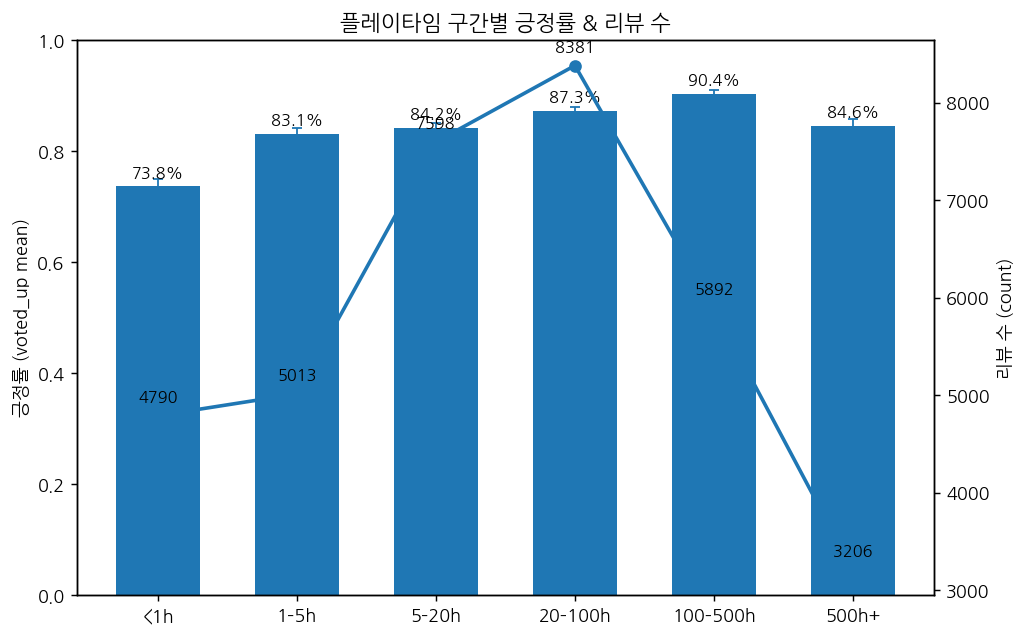

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# 0) 유틸: 윌슨 신뢰구간 (95%) — 표본수가 큰 구간일 때 안정적
# ──────────────────────────────────────────────────────────────────────────────
from math import sqrt
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = p + z*z/(2*n)
    adj = z * sqrt((p*(1-p) + z*z/(4*n)) / n)
    lower = (centre - adj) / denom
    upper = (centre + adj) / denom
    return lower, upper

# ──────────────────────────────────────────────────────────────────────────────
# 1) 전처리
# ──────────────────────────────────────────────────────────────────────────────
def clean_df(df):
    df = df.copy()
    # 필요한 컬럼만, 타입 강제
    needed = ['author_playtime_forever', 'voted_up']
    df = df[needed].dropna()
    # 음수/무한값 제거
    df = df[np.isfinite(df['author_playtime_forever'])]
    df = df[df['author_playtime_forever'] >= 0]
    # voted_up 이진화
    df['voted_up'] = (df['voted_up'] > 0).astype(int)
    return df

# ──────────────────────────────────────────────────────────────────────────────
# 2) 구간 정의 (로그 스케일 감각의 구간)
#    플레이타임은 분 단위 가정.
#    <1h, 1–5h, 5–20h, 20–100h, 100–500h, 500h+
# ──────────────────────────────────────────────────────────────────────────────
BIN_EDGES = [0, 60, 300, 1200, 6000, 30000, np.inf]
BIN_LABELS = ["<1h", "1–5h", "5–20h", "20–100h", "100–500h", "500h+"]

def bin_and_aggregate(df):
    df = clean_df(df)
    df['playtime_bin'] = pd.cut(
        df['author_playtime_forever'],
        bins=BIN_EDGES,
        labels=BIN_LABELS,
        right=False,  # [low, high)
        include_lowest=True,
        ordered=True
    )

    # 집계
    agg = df.groupby('playtime_bin', observed=False).agg(
        PosRate=('voted_up', 'mean'),
        ReviewCount=('voted_up', 'size'),
        PosCount=('voted_up', 'sum')
    ).reset_index()

    # 윌슨 95% CI
    ci = agg.apply(lambda r: wilson_ci(r['PosCount'], r['ReviewCount']), axis=1, result_type='expand')
    agg['PosRate_LB'] = ci[0]
    agg['PosRate_UB'] = ci[1]

    return agg

# ──────────────────────────────────────────────────────────────────────────────
# 3) 시각화: 막대(긍정률) + 우측축 선(리뷰 수)
#    - matplotlib만 사용
#    - 색상 지정 X (기본값 사용)
#    - 단일 플롯 (subplots 금지)
# ──────────────────────────────────────────────────────────────────────────────
def plot_playtime_vs_positive(df, title="Playtime vs Positive Rate"):
    agg = bin_and_aggregate(df)

    x = np.arange(len(agg))
    y_rate = agg['PosRate'].values
    y_cnt  = agg['ReviewCount'].values

    fig, ax1 = plt.subplots(figsize=(8, 5), dpi=130)

    # 막대: 긍정률
    bars = ax1.bar(x, y_rate, width=0.6)
    ax1.set_ylim(0, 1)
    ax1.set_ylabel("긍정률 (voted_up mean)")
    ax1.set_xticks(x, agg['playtime_bin'].astype(str))
    ax1.set_title(title)

    # 윌슨 CI 에러바
    yerr_lower = y_rate - agg['PosRate_LB'].values
    yerr_upper = agg['PosRate_UB'].values - y_rate
    ax1.errorbar(
        x, y_rate, yerr=[yerr_lower, yerr_upper],
        fmt='none', capsize=3, linewidth=1
    )

    # 우측축: 리뷰 수 (선)
    ax2 = ax1.twinx()
    ax2.plot(x, y_cnt, marker='o', linewidth=2)
    ax2.set_ylabel("리뷰 수 (count)")

    # 막대 위 간단 주석 (리뷰 수)
    for xi, cnt, rate in zip(x, y_cnt, y_rate):
        ax2.annotate(f"{int(cnt)}", (xi, cnt), xytext=(0, 6),
                     textcoords="offset points", ha='center', va='bottom', fontsize=9)
        # 막대 위에 긍정률도 퍼센트로
        ax1.annotate(f"{rate*100:.1f}%", (xi, rate), xytext=(0, 3),
                     textcoords="offset points", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    return agg

# ──────────────────────────────────────────────────────────────────────────────
# 4) 사용 예시
# ──────────────────────────────────────────────────────────────────────────────
agg_table = plot_playtime_vs_positive(df, title="플레이타임 구간별 긍정률 & 리뷰 수")
display(agg_table)


=== GLM+Spline 결과 ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:               voted_up   No. Observations:                34880
Model:                            GLM   Df Residuals:                    34874
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14768.
Date:                Fri, 19 Sep 2025   Deviance:                       29536.
Time:                        00:26:29   Pearson chi2:                 3.49e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01733
Covariance Type:            nonrobust                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

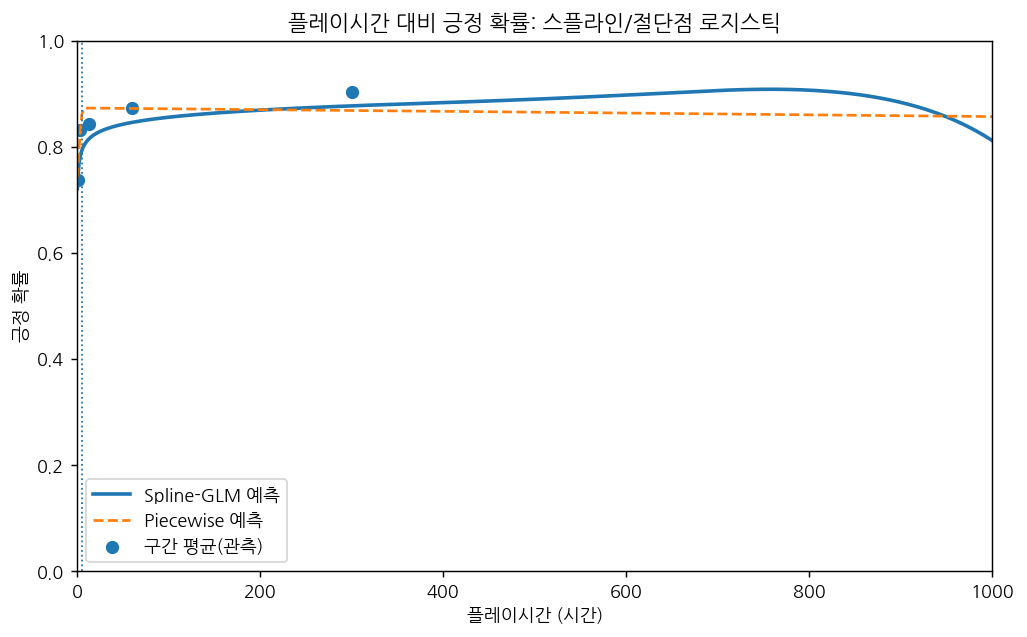

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import patsy as pt
from itertools import product

# ──────────────────────────────────────────────────────────────────────────────
# 0) 데이터 준비
# ──────────────────────────────────────────────────────────────────────────────
def prep(df, controls=None, max_hours=2000, sample_n=None, random_state=42):
    """
    df: 원본 DataFrame
    controls: 통제 변수 리스트 (예: ['author_num_games_owned','author_num_reviews','steam_purchase','received_for_free'])
    max_hours: 이상치 컷(시간 단위). 그 이상은 상한 절삭.
    sample_n: 대용량일 때 성능 확보를 위해 샘플 수 지정(예: 200_000)
    """
    use = df[['author_playtime_forever','voted_up'] + (controls or [])].dropna().copy()
    use = use[np.isfinite(use['author_playtime_forever'])]
    use = use[use['author_playtime_forever'] >= 0]
    # 분 → 시간
    use['playtime_h'] = use['author_playtime_forever'] / 60.0
    # 상한 절삭(heavy tail 안정화)
    use.loc[use['playtime_h'] > max_hours, 'playtime_h'] = max_hours
    # 이진화 보장
    use['voted_up'] = (use['voted_up'] > 0).astype(int)

    # 일부 범주형 더미화(선택): steam_purchase / received_for_free 등 0/1은 그대로 사용
    # language 같은 고카디널 범주는 제외(모형 폭발). 필요하면 상위 k개만 사용 권장.

    # 샘플링(선택)
    if (sample_n is not None) and (len(use) > sample_n):
        use = use.sample(sample_n, random_state=random_state)

    return use

# ──────────────────────────────────────────────────────────────────────────────
# A) GLM Binomial + 자연 cubic spline
# ──────────────────────────────────────────────────────────────────────────────
def fit_glm_spline(df_use, controls=None, df_spline=5):
    """
    df_spline: 스플라인 자유도(기본 5). 과적합 방지를 위해 4~6 권장.
    """
    controls = controls or []
    # 로그 스케일 효과를 반영하고 0 방지 위해 log1p 사용
    df_use['logh'] = np.log1p(df_use['playtime_h'])

    # 디자인 행렬: 자연 cubic spline(bs) + 통제변수
    # patsy의 bs()는 B-spline basis를 생성. degree=3(기본), include_intercept=False.
    spline_term = f'bs(logh, df={df_spline}, include_intercept=False)'
    formula_rhs = ' + '.join([spline_term] + controls) if controls else spline_term
    y, X = pt.dmatrices(f'voted_up ~ {formula_rhs}', data=df_use, return_type='dataframe')

    # GLM(Binomial, logit link)
    model = sm.GLM(y, X, family=sm.families.Binomial())
    res = model.fit()
    return res, X.columns.tolist()

def spline_predict_and_peak(res, df_use, df_spline=5, grid_hours=(0, 1000), num=400):
    # 예측 그리드(시간 → log1p 변환)
    h_grid = np.linspace(grid_hours[0], grid_hours[1], num=num)
    grid = pd.DataFrame({'playtime_h': h_grid})
    grid['logh'] = np.log1p(grid['playtime_h'])

    # 디자인 행렬 재생성
    Xg = pt.dmatrix(f'bs(logh, df={df_spline}, include_intercept=False)', data=grid, return_type='dataframe')
    # res.params는 spline 베이시스 계수만 포함(통제 미사용 가정). 통제가 있다면 0으로 채운 열을 추가해야 함.
    # 간단화를 위해 res.model.exog_names를 기준으로 열 정렬/보정
    for col in res.model.exog_names:
        if col not in Xg.columns:
            Xg[col] = 0.0
    Xg = Xg[res.model.exog_names]

    # 예측 확률
    mu = res.predict(Xg)
    grid['pred'] = mu
    # 최댓값 위치
    idx = int(np.nanargmax(mu))
    peak_h = float(grid.loc[idx, 'playtime_h'])
    peak_p = float(grid.loc[idx, 'pred'])
    return grid, (peak_h, peak_p)

# ──────────────────────────────────────────────────────────────────────────────
# B) 단일 절단점(piecewise) 로지스틱: (h <= k)와 (h > k)에서 서로 다른 기울기
# ──────────────────────────────────────────────────────────────────────────────
def piecewise_design(h, k):
    """
    segmented logit: logit(p) = b0 + b1*h + b2*(h - k)_+
    (h - k)_+ = max(h - k, 0)
    """
    h = np.asarray(h)
    return np.column_stack([np.ones_like(h), h, np.clip(h - k, 0, None)])

def fit_piecewise_best_k(df_use, k_grid=None):
    """
    k_grid: 절단점 후보(시간). None이면 데이터 분위수 기반 자동 설정.
    """
    y = df_use['voted_up'].values
    h = df_use['playtime_h'].values

    if k_grid is None:
        qs = np.quantile(h, [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
        k_grid = np.unique(np.round(qs, 2))

    best = None
    for k in k_grid:
        X = piecewise_design(h, k)
        model = sm.GLM(y, X, family=sm.families.Binomial())
        try:
            res = model.fit()
            aic = res.aic
            if (best is None) or (aic < best['aic']):
                best = {'k': k, 'res': res, 'aic': aic}
        except Exception:
            continue
    return best  # {'k', 'res', 'aic'}

def piecewise_predict(best, hours_grid):
    Xg = piecewise_design(hours_grid, best['k'])
    mu = best['res'].predict(Xg)
    return mu

# ──────────────────────────────────────────────────────────────────────────────
# 1) 실행 예시
# ──────────────────────────────────────────────────────────────────────────────
# 통제 변수(옵션): 대규모 데이터에서는 최소한의 통제만 권장
controls = ['author_num_games_owned','author_num_reviews','steam_purchase','received_for_free']  # 없으면 빈 리스트로
df_use = prep(df, controls=[], max_hours=2000, sample_n=None)

# A) 스플라인 로지스틱
spline_df = 5
res_spline, names = fit_glm_spline(df_use, controls=[], df_spline=spline_df)
grid, peak = spline_predict_and_peak(res_spline, df_use, df_spline=spline_df, grid_hours=(0, 1000), num=500)
peak_h, peak_p = peak

print("=== GLM+Spline 결과 ===")
print(res_spline.summary())
print(f"\n스플라인 추정 Peak: 약 {peak_h:.1f} 시간에서 긍정 확률 {peak_p*100:.2f}% (그리드 추정)")

# B) Piecewise 로지스틱(단일 절단점)
best = fit_piecewise_best_k(df_use, k_grid=None)
if best is not None:
    print("\n=== Piecewise 결과 ===")
    print(f"최적 절단점 k ≈ {best['k']:.1f} 시간 (AIC={best['aic']:.1f})")
else:
    print("\nPiecewise 적합 실패(수치 문제)")

# ──────────────────────────────────────────────────────────────────────────────
# 2) 시각화 (예측 확률 곡선 + 관측 구간 평균 점찍기)
#   - matplotlib만 사용
#   - 단일 플롯, 색 지정 X
# ──────────────────────────────────────────────────────────────────────────────
# 관측 구간 평균(이전에 쓰던 bin 정의 재사용)
BIN_EDGES = [0, 1, 5, 20, 100, 500, 2000]  # 시간 단위
BIN_LABELS = ["<1h", "1–5h", "5–20h", "20–100h", "100–500h", "500h+"]

tmp = df_use.copy()
tmp['bin'] = pd.cut(tmp['playtime_h'], bins=BIN_EDGES, labels=BIN_LABELS, right=False, include_lowest=True, ordered=True)
agg = tmp.groupby('bin', observed=False)['voted_up'].agg(['mean','size']).reset_index()

fig, ax = plt.subplots(figsize=(8,5), dpi=130)
# 스플라인 예측 곡선
ax.plot(grid['playtime_h'], grid['pred'], linewidth=2, label='Spline-GLM 예측')

# piecewise 예측(있으면)
if best is not None:
    h_line = np.linspace(0, 1000, 400)
    mu_pw = piecewise_predict(best, h_line)
    ax.plot(h_line, mu_pw, linewidth=1.5, linestyle='--', label='Piecewise 예측')
    # 절단점 표시
    ax.axvline(best['k'], linewidth=1, linestyle=':')

# 관측 구간 평균(마커)
centers = []
for (lo, hi), m in zip(zip(BIN_EDGES[:-1], BIN_EDGES[1:]), agg['mean'].values):
    centers.append((lo+hi)/2.0)
ax.scatter(centers, agg['mean'].values, s=40, label='구간 평균(관측)')

ax.set_ylim(0, 1)
ax.set_xlim(0, 1000)
ax.set_xlabel("플레이시간 (시간)")
ax.set_ylabel("긍정 확률")
ax.set_title("플레이시간 대비 긍정 확률: 스플라인/절단점 로지스틱")
ax.legend()
plt.tight_layout()


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

def model_explanatory_power(df_use, res_spline):
    # 실제값
    y_true = df_use['voted_up'].values
    # 예측 확률
    y_pred = res_spline.predict()

    # 1. Pseudo-R² (McFadden)
    ll_model = res_spline.llf
    ll_null = sm.GLM(y_true, np.ones((len(y_true),1)),
                     family=sm.families.Binomial()).fit().llf
    pseudo_r2 = 1 - (ll_model / ll_null)

    # 2. AUC
    auc = roc_auc_score(y_true, y_pred)

    # 3. Accuracy (임계값=0.5)
    y_label = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_label)

    # 4. AIC, BIC
    aic = res_spline.aic
    bic = res_spline.bic

    print("=== 설명력 지표 ===")
    print(f"McFadden Pseudo-R² : {pseudo_r2:.4f}")
    print(f"ROC-AUC            : {auc:.4f}")
    print(f"Accuracy (cut=0.5) : {acc:.4f}")
    print(f"AIC                : {aic:.1f}")
    print(f"BIC                : {bic:.1f}")

    return {
        "Pseudo_R2": pseudo_r2,
        "AUC": auc,
        "Accuracy": acc,
        "AIC": aic,
        "BIC": bic
    }

# 사용 예시
metrics = model_explanatory_power(df_use, res_spline)


=== 설명력 지표 ===
McFadden Pseudo-R² : 0.0202
ROC-AUC            : 0.6009
Accuracy (cut=0.5) : 0.8445
AIC                : 29548.2
BIC                : -335234.3


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


#20개fps게임목록

In [ ]:
import pandas as pd

# 확인할 appid 리스트
target_ids = [
    730, 578080, 1172470, 2507950, 359550, 1085660, 2357570,
    252490, 440, 1144200, 2073850, 1282270, 493520, 1217060,
    444200, 107410, 550, 1874880, 1517290, 393380, 1237970, 699130, 2000950
]

# df의 appid 컬럼에 있는지 여부 체크
exists_mask = df['appid'].isin(target_ids)

# 실제로 존재하는 appid만 추출
present_ids = df.loc[exists_mask, 'appid'].unique()

# 없는 appid 확인
missing_ids = set(target_ids) - set(present_ids)

print("데이터프레임 안에 존재하는 appid:")
print(present_ids)

print("\n데이터프레임 안에 없는 appid:")
print(missing_ids)


데이터프레임 안에 존재하는 appid:
[ 107410 1085660 1144200 1172470 1217060 1237970 1517290 1874880 2000950
 2357570  252490  359550  393380     440  444200  493520     550  578080
  699130     730]

데이터프레임 안에 없는 appid:
{2073850, 1282270, 2507950}


#석진님이 만들어주신 csv파일로 작업진행


In [ ]:
import pandas as pd

path = '/content/FPS_steam_reviews_20_games.csv'

df = pd.read_csv(
    path,
    engine="python",      # python 엔진 사용
    on_bad_lines="skip"   # 문제 행 건너뜀
)




/tmp/ipython-input-1379071788.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("play_bin").agg(


  play_bin   PosRate  ReviewCount
0     1-5m  0.751808         2212
1    5-20m  0.767488         1501
2     20m+  0.760909         1100


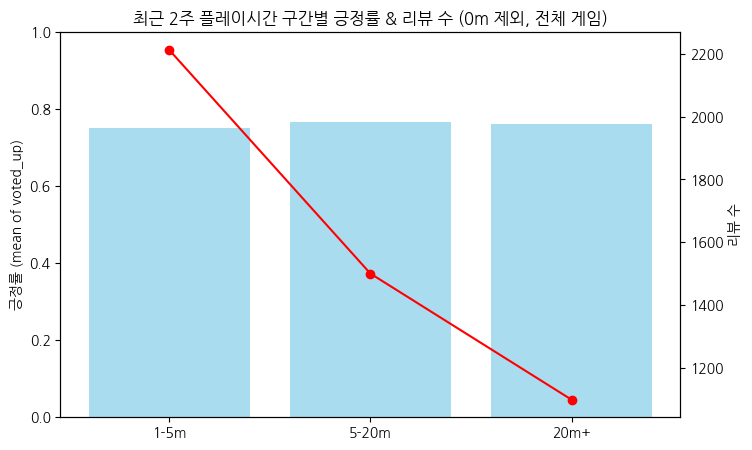

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 1. 플레이시간 구간화
# -----------------------
bins = [0, 300, 1200, float("inf")]
labels = ["1-5m", "5-20m", "20m+"]


df["play_bin"] = pd.cut(df["author_playtime_last_two_weeks"], bins=bins, labels=labels)

# -----------------------
# 2. 집계 (긍정률 + 리뷰 수)
# -----------------------
summary = df.groupby("play_bin").agg(
    PosRate=("voted_up", "mean"),
    ReviewCount=("voted_up", "count")
).reset_index()

print(summary)

# -----------------------
# 3. 시각화
# -----------------------
fig, ax1 = plt.subplots(figsize=(8,5))

# 긍정률 (왼쪽 y축, 막대그래프)
ax1.bar(summary["play_bin"], summary["PosRate"], color="skyblue", alpha=0.7, label="PosRate")
ax1.set_ylabel("긍정률 (mean of voted_up)")
ax1.set_ylim(0,1)

# 리뷰 수 (오른쪽 y축, 선 그래프)
ax2 = ax1.twinx()
ax2.plot(summary["play_bin"], summary["ReviewCount"], color="red", marker="o", label="Review Count")
ax2.set_ylabel("리뷰 수")

plt.title("최근 2주 플레이시간 구간별 긍정률 & 리뷰 수 (0m 제외, 전체 게임)")
plt.show()


In [ ]:
# 0h 초과 데이터만 필터링
df_use = df[df["author_playtime_last_two_weeks"] > 0].copy()

# 행 개수 확인
print("최근 2주 플레이시간 > 0h 인 행 개수:", df_use.shape[0])


최근 2주 플레이시간 > 0h 인 행 개수: 4813


#가설 1-3: 소유한 게임 수



Silhouette (sampled):
K=2: silhouette=0.3400
K=3: silhouette=0.3198
K=4: silhouette=0.2801
K=5: silhouette=0.2616
K=6: silhouette=0.2475
[INFO] 강제로 선택된 최종 K = 4
----------- [이상치 처리 후 군집별 특성] -----------
         author_num_games_owned  author_num_reviews  author_playtime_forever
cluster                                                                     
0                    158.546469           12.035441               296.851396
1                    829.768567           75.167352               634.632871
2                     92.685825            5.578453              7012.669835
3                    478.051704           35.732790              6371.886014

[클러스터 → 게이머 유형 매핑]
   cluster gamer_type
0        0   LightMid
1        1  SuperCore
2        2   LightMid
3        3       Core

== PosRate by cluster ==
          PosRate      N
cluster                 
0        0.848915  63289
1        0.855983  67110
2        0.879483  74172
3        0.898121  84993

== PosRate by gamer_type ==


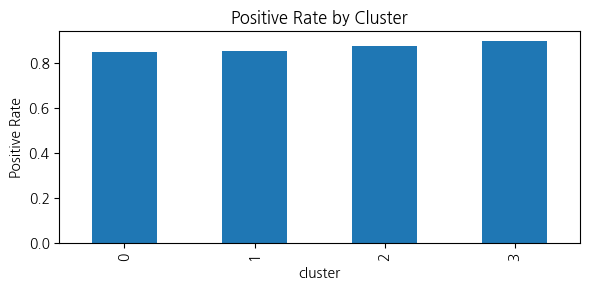

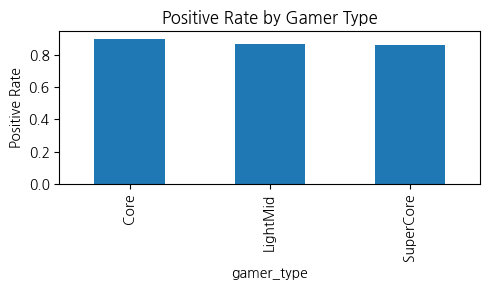

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------
# 0) 준비
# ----------------------------
FEATURES = ['author_num_games_owned', 'author_num_reviews', 'author_playtime_forever']
TARGET   = 'voted_up'   # 0/1

use_cols = FEATURES + [TARGET]
df_use = df[use_cols].dropna().copy()

# ----------------------------
# 1) IQR 윈저라이즈 (벡터화, 빠르게)
# ----------------------------
def iqr_winsorize_fast(s: pd.Series, k=1.5):
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return s.clip(lower=lo, upper=hi)

for c in FEATURES:
    df_use[c] = iqr_winsorize_fast(df_use[c].astype('float64'), k=1.5)

# ----------------------------
# 2) log1p + 표준화 (float32로)
# ----------------------------
def log1p_safe_array(x):
    x = np.asarray(x)
    return np.log1p(np.maximum(x, 0))

X_num = df_use[FEATURES].values
X_num = log1p_safe_array(X_num).astype('float32')

scaler = StandardScaler()
X = scaler.fit_transform(X_num).astype('float32')
y = df_use[TARGET].astype('int8').values

# ----------------------------
# 3) K 탐색 (빠른 모드)
#    - 실루엣/엘보 계산은 샘플(<=10_000)
#    - MiniBatchKMeans로 속도↑
# ----------------------------
rng = np.random.default_rng(42)
MAX_SIL_SAMPLES = 10_000
n = X.shape[0]
if n > MAX_SIL_SAMPLES:
    idx_sil = rng.choice(n, size=MAX_SIL_SAMPLES, replace=False)
    X_sil = X[idx_sil]
else:
    X_sil = X

Ks = range(2, 7)  # 2~6만 탐색 (충분히 실무적)
inertias = []
sil_scores = []

for k in Ks:
    mbk = MiniBatchKMeans(
        n_clusters=k, random_state=42, n_init=5, batch_size=2048, max_iter=100
    )
    mbk.fit(X)  # 전체로 학습(빠름)
    inertias.append(mbk.inertia_)
    # 실루엣은 샘플만
    sil_scores.append(silhouette_score(X_sil, mbk.predict(X_sil)))

# (선택) 간단 출력만
print("Silhouette (sampled):")
for k, s in zip(Ks, sil_scores):
    print(f"K={k}: silhouette={s:.4f}")

# ----------------------------
# 4) 최종 K 선택 휴리스틱
#    - 실루엣 최대 K 또는 관성(엘보) 추세로 결정
# ----------------------------
#K_FINAL = Ks[int(np.argmax(sil_scores))]
#print(f"[INFO] 선택된 최종 K = {K_FINAL}")

# 최종 학습은 일반 KMeans(Elkan)로 조금 더 정밀하게
#kmeans = KMeans(n_clusters=K_FINAL, n_init=10, algorithm='elkan', random_state=42)
#labels = kmeans.fit_predict(X)

#df_out = df_use.copy()
#df_out['cluster'] = labels

# ... 위 코드는 그대로 두고 ...

# ----------------------------
# 4) 최종 K 선택 (강제 고정)
# ----------------------------
K_FINAL = 4   # <- 강제로 4로 지정
print(f"[INFO] 강제로 선택된 최종 K = {K_FINAL}")

kmeans = KMeans(n_clusters=K_FINAL, n_init=10, algorithm='elkan', random_state=42)
labels = kmeans.fit_predict(X)

df_out = df_use.copy()
df_out['cluster'] = labels


# ----------------------------
# 5) 클러스터 프로파일 (원본 스케일 평균)
# ----------------------------
cluster_profile = (
    df_out.groupby('cluster')[FEATURES]
    .mean(numeric_only=True)
    .sort_index()
)
print("----------- [이상치 처리 후 군집별 특성] -----------")
print(cluster_profile)

# ----------------------------
# 6) 게이머 유형 라벨링 (상대백분위)
# ----------------------------
ranked = cluster_profile.rank(pct=True)  # 0~1
labels_map = {}
for cl in cluster_profile.index:
    g = ranked.loc[cl, 'author_num_games_owned']
    r = ranked.loc[cl, 'author_num_reviews']
    if (g >= 0.90) and (r >= 0.90):
        labels_map[cl] = 'SuperCore'
    elif (g >= 0.75) and (r >= 0.75):
        labels_map[cl] = 'Core'
    else:
        labels_map[cl] = 'LightMid'
df_out['gamer_type'] = df_out['cluster'].map(labels_map)

print("\n[클러스터 → 게이머 유형 매핑]")
print(pd.DataFrame({'cluster': list(labels_map.keys()),
                    'gamer_type': list(labels_map.values())}).sort_values('cluster'))

# ----------------------------
# 7) 집단별 긍정률 + 카이제곱
# ----------------------------
posrate_by_cluster = df_out.groupby('cluster')[TARGET].agg(PosRate='mean', N='count')
posrate_by_type    = df_out.groupby('gamer_type')[TARGET].agg(PosRate='mean', N='count')

print("\n== PosRate by cluster ==")
print(posrate_by_cluster.sort_index())

print("\n== PosRate by gamer_type ==")
print(posrate_by_type.sort_values('PosRate'))

ct = pd.crosstab(df_out['cluster'], df_out[TARGET])
chi2, p, dof, exp = stats.chi2_contingency(ct.values)  # values로 약간 빠르게
print("\n== Chi-square (cluster x voted_up) ==")
print(f"chi2={chi2:.4f}, p={p:.3e}, dof={dof}")

# ----------------------------
# 8) 로지스틱 회귀 (빠른 옵션)
#    - 표본 100k만 사용해 statsmodels GLM (요약출력 안 함)
#    - 전량이 꼭 필요 없으면 이게 훨씬 빠름
# ----------------------------
MAX_GLM_SAMPLES = 100_000
m = len(df_out)
if m > MAX_GLM_SAMPLES:
    idx_glm = rng.choice(m, size=MAX_GLM_SAMPLES, replace=False)
    df_glm = df_out.iloc[idx_glm].copy()
else:
    df_glm = df_out.copy()

df_glm['gamer_type'] = pd.Categorical(df_glm['gamer_type'], categories=['LightMid','Core','SuperCore'])

# 요약은 무겁고 길게 찍히니 비활성화
glm_model = smf.glm(formula='voted_up ~ C(gamer_type)', data=df_glm,
                    family=sm.families.Binomial()).fit(disp=False)

params = glm_model.params
conf   = glm_model.conf_int()
odds   = np.exp(params)
odds_ci= np.exp(conf)
odds_table = pd.DataFrame({'OR': odds, 'CI_low': odds_ci[0], 'CI_high': odds_ci[1]})
print("\n=== GLM(Logit) OR & 95% CI (sampled) ===")
print(odds_table)

# ----------------------------
# 9) (선택) 가벼운 시각화만
# ----------------------------
ax = posrate_by_cluster['PosRate'].plot(kind='bar', figsize=(6,3), title='Positive Rate by Cluster')
ax.set_ylabel('Positive Rate')
plt.tight_layout(); plt.show()

ax = posrate_by_type['PosRate'].plot(kind='bar', figsize=(5,3), title='Positive Rate by Gamer Type')
ax.set_ylabel('Positive Rate')
plt.tight_layout(); plt.show()


/tmp/ipython-input-2513642453.py:68: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


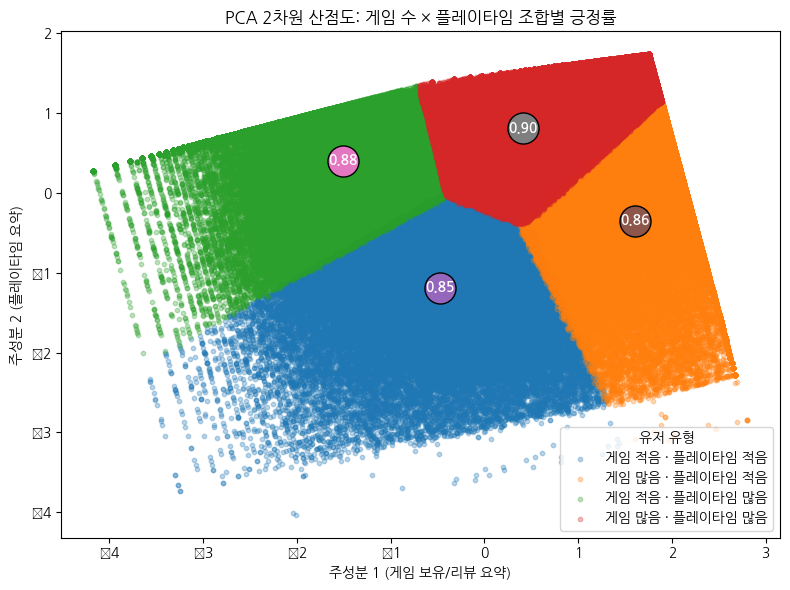

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------------------
# A) PCA 2차원 임베딩 (기존 표준화된 X를 사용)
# -----------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)                       # X: 위에서 만든 표준화(로그) 특징 행렬
centers_pca = pca.transform(kmeans.cluster_centers_)  # 클러스터 중심을 PCA 공간으로 투영

# -----------------------------------------
# B) 시각화용 데이터프레임 구성
# -----------------------------------------
df_plot = pd.DataFrame({
    "주성분1": X_pca[:, 0],
    "주성분2": X_pca[:, 1],
    "클러스터": labels,                          # kmeans.fit_predict 결과
    "voted_up": df_out["voted_up"].values        # 원본 라벨
})

# 클러스터 중심점 (PCA 좌표)
cluster_centers = pd.DataFrame(
    centers_pca,
    columns=["주성분1", "주성분2"]
)

# 클러스터별 긍정률 (Series)
posrate_by_cluster_mean = df_plot.groupby("클러스터")["voted_up"].mean()

# -----------------------------------------
# C) 라벨 매핑 (게임수 × 플레이타임 조합)
# -----------------------------------------
cluster_labels = {
    0: "게임 적음 · 플레이타임 적음",
    1: "게임 많음 · 플레이타임 적음",
    2: "게임 적음 · 플레이타임 많음",
    3: "게임 많음 · 플레이타임 많음",
}
df_plot["유저유형"] = df_plot["클러스터"].map(cluster_labels)

# -----------------------------------------
# D) 산점도
# -----------------------------------------
plt.figure(figsize=(8,6))

# 개별 점
for cl in sorted(df_plot["클러스터"].unique()):
    subset = df_plot[df_plot["클러스터"] == cl]
    plt.scatter(
        subset["주성분1"], subset["주성분2"],
        s=10, alpha=0.3, label=cluster_labels.get(cl, f"cluster {cl}")
    )

# 클러스터 중심 + 긍정률 표시
for cl, row in cluster_centers.iterrows():
    pr = float(posrate_by_cluster_mean.loc[cl])
    plt.scatter(row["주성분1"], row["주성분2"], s=500, marker="o", edgecolor="k")
    plt.text(row["주성분1"], row["주성분2"], f"{pr:.2f}",
             ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.title("PCA 2차원 산점도: 게임 수 × 플레이타임 조합별 긍정률")
plt.xlabel("주성분 1 (게임 보유/리뷰 요약)")
plt.ylabel("주성분 2 (플레이타임 요약)")
plt.legend(title="유저 유형", loc="best")
plt.tight_layout()
plt.show()


####플레이타임 vs 긍정률

그룹 간 차이:

플레이타임 구간별 긍정률 분포 비교 → Kruskal-Wallis test (3집단 이상)

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# -------------------------------------------
# 1) 플레이터임(분) 구간 정의 & 라벨
#    - 필요에 맞게 bins/labels 수정하세요
# -------------------------------------------
# 예: 0~60분, 1~5시간(60~300), 5~20시간(300~1200), 20~100시간(1200~6000), 100시간 이상(6000+)
bins_min = [0, 60, 300, 1200, 6000, np.inf]
labels   = ["<1h", "1-5h", "5-20h", "20-100h", "100h+"]

# df: 원본 데이터프레임, 컬럼: 'author_playtime_forever'(분), 'voted_up'(0/1)
df_kr = df[['author_playtime_forever', 'voted_up']].dropna().copy()

# 필요 시: 최근 2주 플레이타임으로 바꾸려면 컬럼명만 변경
# df_kr = df[['author_playtime_last_two_weeks', 'voted_up']].dropna().copy()
# df_kr.rename(columns={'author_playtime_last_two_weeks':'author_playtime_forever'}, inplace=True)

# 0분 초과만 사용할 경우(원하시면 주석 해제)
# df_kr = df_kr[df_kr['author_playtime_forever'] > 0]

df_kr['play_bin'] = pd.cut(df_kr['author_playtime_forever'], bins=bins_min, labels=labels, right=False)

# -------------------------------------------
# 2) 기술통계: 구간별 긍정률 & 표본수
# -------------------------------------------
summary = (df_kr
           .groupby('play_bin')['voted_up']
           .agg(PosRate='mean', N='count')
           .reset_index())
print("== PosRate by playtime bin ==")
print(summary)

# -------------------------------------------
# 3) Kruskal–Wallis test (3집단 이상)
#    귀무가설: 모든 구간의 분포(중앙값)가 동일
# -------------------------------------------
groups = []
group_names = []
for g in labels:
    vals = df_kr.loc[df_kr['play_bin'] == g, 'voted_up'].values
    if len(vals) > 0:
        groups.append(vals)
        group_names.append(g)

if len(groups) >= 3:
    H, p_kw = stats.kruskal(*groups)   # 비모수 ANOVA 대안
    print(f"\n== Kruskal–Wallis ==")
    print(f"H={H:.4f}, p-value={p_kw:.3e}")
else:
    print("\n[WARN] 유효한 그룹이 3개 미만입니다. Kruskal–Wallis 불가.")

# -------------------------------------------
# 4) (선택) 사후검정: Mann–Whitney U + Holm 보정
#    귀무가설: 두 구간의 분포가 동일
# -------------------------------------------
do_posthoc = True
if do_posthoc and len(groups) >= 2:
    from itertools import combinations
    pairs, pvals = [], []

    # 모든 쌍에 대해 양측 Mann–Whitney U
    for (g1, g2) in combinations(range(len(group_names)), 2):
        x = df_kr.loc[df_kr['play_bin'] == group_names[g1], 'voted_up'].values
        y = df_kr.loc[df_kr['play_bin'] == group_names[g2], 'voted_up'].values
        if len(x) > 0 and len(y) > 0:
            # 동일값/타이 처리 위해 alternative='two-sided'
            U, p = stats.mannwhitneyu(x, y, alternative='two-sided')
            pairs.append((group_names[g1], group_names[g2]))
            pvals.append(p)

    if pvals:
        rej, p_adj, _, _ = multipletests(pvals, alpha=0.05, method='holm')
        posthoc = pd.DataFrame({
            'group1': [a for a,b in pairs],
            'group2': [b for a,b in pairs],
            'p_raw': pvals,
            'p_holm': p_adj,
            'reject@0.05': rej
        }).sort_values('p_holm')
        print("\n== Post-hoc: Mann–Whitney U (Holm-adjusted) ==")
        print(posthoc.to_string(index=False))
    else:
        print("\n[INFO] 사후검정에 사용할 유효한 페어가 없습니다.")


/tmp/ipython-input-1069741645.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('play_bin')['voted_up']


== PosRate by playtime bin ==
  play_bin   PosRate      N
0      <1h  0.722614  22402
1     1-5h  0.851473  43110
2    5-20h  0.894389  72303
3  20-100h  0.901214  81358
4    100h+  0.878749  70391

== Kruskal–Wallis ==
H=5646.6097, p-value=0.000e+00

== Post-hoc: Mann–Whitney U (Holm-adjusted) ==
 group1  group2         p_raw        p_holm  reject@0.05
    <1h    1-5h  0.000000e+00  0.000000e+00         True
    <1h   5-20h  0.000000e+00  0.000000e+00         True
    <1h 20-100h  0.000000e+00  0.000000e+00         True
    <1h   100h+  0.000000e+00  0.000000e+00         True
   1-5h 20-100h 7.287763e-150 4.372658e-149         True
   1-5h   5-20h 2.990691e-103 1.495345e-102         True
20-100h   100h+  1.727742e-44  6.910969e-44         True
   1-5h   100h+  9.724722e-40  2.917417e-39         True
  5-20h   100h+  1.184550e-20  2.369100e-20         True
  5-20h 20-100h  1.021292e-05  1.021292e-05         True


In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Core 집단(cluster=3) 제거
df_sub = df_out[df_out['cluster'] != 3].copy()

# 집단별 기술통계
summary = df_sub.groupby('cluster')['voted_up'].agg(PosRate='mean', N='count')
print("== PosRate by cluster (Core 제거) ==")
print(summary)

# Kruskal–Wallis 검정
groups = [df_sub.loc[df_sub['cluster']==cl, 'voted_up'].values
          for cl in sorted(df_sub['cluster'].unique())]

H, p_kw = stats.kruskal(*groups)
print(f"\n== Kruskal–Wallis (clusters 0/1/2) ==")
print(f"H={H:.4f}, p-value={p_kw:.3e}")

# 사후검정 (Mann–Whitney U + Holm 보정)
pairs, pvals = [], []
clusters = sorted(df_sub['cluster'].unique())
for g1, g2 in combinations(clusters, 2):
    x = df_sub.loc[df_sub['cluster']==g1, 'voted_up'].values
    y = df_sub.loc[df_sub['cluster']==g2, 'voted_up'].values
    U, p = stats.mannwhitneyu(x, y, alternative='two-sided')
    pairs.append((g1, g2)); pvals.append(p)

rej, p_adj, _, _ = multipletests(pvals, alpha=0.05, method='holm')
posthoc = pd.DataFrame({
    'cluster1': [a for a,b in pairs],
    'cluster2': [b for a,b in pairs],
    'p_raw': pvals,
    'p_holm': p_adj,
    'reject@0.05': rej
})
print("\n== Post-hoc (Mann–Whitney U, Holm 보정) ==")
print(posthoc)


== PosRate by cluster (Core 제거) ==
          PosRate      N
cluster                 
0        0.848915  63289
1        0.855983  67110
2        0.879483  74172

== Kruskal–Wallis (clusters 0/1/2) ==
H=302.5059, p-value=2.050e-66

== Post-hoc (Mann–Whitney U, Holm 보정) ==
   cluster1  cluster2         p_raw        p_holm  reject@0.05
0         0         1  3.212914e-04  3.212914e-04         True
1         0         2  1.564406e-61  4.693217e-61         True
2         1         2  6.799699e-39  1.359940e-38         True


In [ ]:
import numpy as np
from scipy import stats

# ----------------------------
# 1) Epsilon-squared (Kruskal–Wallis 효과크기)
# ----------------------------
n_total = len(df_sub)                     # 표본 전체 크기
k = df_sub['cluster'].nunique()           # 집단 수
epsilon_sq = (H - k + 1) / (n_total - k)  # H는 kruskal 결과
print(f"Epsilon-squared: {epsilon_sq:.4f}")

# ----------------------------
# 2) Cramer's V (교차표 기반 효과크기)
# ----------------------------
ct = pd.crosstab(df_sub['cluster'], df_sub['voted_up'])
chi2, p_chi, dof, exp = stats.chi2_contingency(ct)

cramers_v = np.sqrt(chi2 / (n_total * (min(ct.shape)-1)))
print(f"Cramer's V: {cramers_v:.4f}")


Epsilon-squared: 0.0015
Cramer's V: 0.0385


---------------------------

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

# df_out: 이전 단계에서 만든 데이터프레임 (cluster, gamer_type, voted_up 포함)

# ------------------------------------------------------------
# 1. 집단별 r값 계산 (피어슨 + 스피어만)
# ------------------------------------------------------------
results_corr = []

for cl in sorted(df_out['cluster'].unique()):
    sub = df_out[df_out['cluster'] == cl]

    # 피어슨
    r_p, p_p = pearsonr(sub['author_playtime_forever'], sub['voted_up'])
    # 스피어만
    r_s, p_s = spearmanr(sub['author_playtime_forever'], sub['voted_up'])

    results_corr.append({
        "cluster": cl,
        "N": len(sub),
        "Pearson_r": r_p, "Pearson_p": p_p,
        "Spearman_r": r_s, "Spearman_p": p_s
    })

df_corr = pd.DataFrame(results_corr)
print("=== 상관분석 결과 (클러스터별) ===")
print(df_corr)

# ------------------------------------------------------------
# 2. 집단별 로지스틱 회귀
#    voted_up ~ log(playtime)
# ------------------------------------------------------------
import numpy as np
df_out['log_playtime'] = np.log1p(df_out['author_playtime_forever'])

logit_results = {}
for cl in sorted(df_out['cluster'].unique()):
    sub = df_out[df_out['cluster'] == cl]

    model = smf.glm(
        formula="voted_up ~ log_playtime",
        data=sub,
        family=sm.families.Binomial()
    ).fit()

    logit_results[cl] = model
    print(f"\n=== Cluster {cl} 회귀 결과 ===")
    print(model.summary())

    # 오즈비 변환
    or_table = pd.DataFrame({
        "OR": np.exp(model.params),
        "CI_low": np.exp(model.conf_int()[0]),
        "CI_high": np.exp(model.conf_int()[1])
    })
    print("\n[Odds Ratio & 95% CI]")
    print(or_table)

# ------------------------------------------------------------
# 3. 결과 해석 포인트
# - df_corr: r값이 유의미한지 (p<0.05)
# - 각 cluster 회귀 결과 coef 해석:
#   log_playtime 양수 → 플레이타임 많을수록 긍정 확률 ↑
#   음수 → 많을수록 긍정 확률 ↓
# ------------------------------------------------------------


=== 상관분석 결과 (클러스터별) ===
   cluster     N  Pearson_r     Pearson_p  Spearman_r    Spearman_p
0        0  3910   0.068841  1.644802e-05    0.071485  7.667898e-06
1        1  2925   0.014145  4.444333e-01    0.006976  7.060644e-01
2        2  2597   0.171080  1.649995e-18    0.274255  4.922212e-46
3        3  3538   0.077760  3.645852e-06    0.074032  1.043412e-05

=== Cluster 0 회귀 결과 ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:               voted_up   No. Observations:                 3910
Model:                            GLM   Df Residuals:                     3908
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2004.6
Date:                Thu, 18 Sep 2025   Deviance:                       4009.3
Time:                        05:57:48   Pearson chi2:     

In [ ]:
# cluster=3 제거
df_out_filtered = df_out[df_out['cluster'] != 3].copy()

# 이후 분석 대상 데이터프레임 교체
for cl in sorted(df_out_filtered['cluster'].unique()):
    sub = df_out_filtered[df_out_filtered['cluster'] == cl]
    ...

# ------------------------------------------------------------
# 1. 집단별 r값 계산 (피어슨 + 스피어만)
# ------------------------------------------------------------
results_corr = []

for cl in sorted(df_out_filtered['cluster'].unique()):
    sub = df_out_filtered[df_out_filtered['cluster'] == cl]

    r_p, p_p = pearsonr(sub['author_playtime_forever'], sub['voted_up'])
    r_s, p_s = spearmanr(sub['author_playtime_forever'], sub['voted_up'])

    results_corr.append({
        "cluster": cl,
        "N": len(sub),
        "Pearson_r": r_p, "Pearson_p": p_p,
        "Spearman_r": r_s, "Spearman_p": p_s
    })

df_corr = pd.DataFrame(results_corr)
print("=== 상관분석 결과 (클러스터별) ===")
print(df_corr)

# ------------------------------------------------------------
# 2. 집단별 로지스틱 회귀
# ------------------------------------------------------------
df_out_filtered['log_playtime'] = np.log1p(df_out_filtered['author_playtime_forever'])

logit_results = {}
for cl in sorted(df_out_filtered['cluster'].unique()):
    sub = df_out_filtered[df_out_filtered['cluster'] == cl]

    model = smf.glm(
        formula="voted_up ~ log_playtime",
        data=sub,
        family=sm.families.Binomial()
    ).fit()

    logit_results[cl] = model
    print(f"\n=== Cluster {cl} 회귀 결과 ===")
    print(model.summary())

    or_table = pd.DataFrame({
        "OR": np.exp(model.params),
        "CI_low": np.exp(model.conf_int()[0]),
        "CI_high": np.exp(model.conf_int()[1])
    })
    print("\n[Odds Ratio & 95% CI]")
    print(or_table)



=== 상관분석 결과 (클러스터별) ===
   cluster     N  Pearson_r     Pearson_p  Spearman_r    Spearman_p
0        0  3910   0.068841  1.644802e-05    0.071485  7.667898e-06
1        1  2925   0.014145  4.444333e-01    0.006976  7.060644e-01
2        2  2597   0.171080  1.649995e-18    0.274255  4.922212e-46

=== Cluster 0 회귀 결과 ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:               voted_up   No. Observations:                 3910
Model:                            GLM   Df Residuals:                     3908
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2004.6
Date:                Thu, 18 Sep 2025   Deviance:                       4009.3
Time:                        05:57:58   Pearson chi2:                 3.91e+03
No. Iterations:                     4   Pseudo 

##집단별 세부 패턴 추가 탐색

###기본 세팅 & 전처리

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np, pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

# df 또는 df_out 을 사용하세요. 여기선 df_out 가정.
assert 'cluster' in df_out.columns, "cluster 컬럼이 필요합니다."
use_cols = [
    'appid','cluster','voted_up',
    'author_playtime_forever','author_num_games_owned',
    'steam_purchase','received_for_free','written_during_early_access'
]
dfu = df_out.copy()
dfu = dfu[[c for c in use_cols if c in dfu.columns]].copy()

# Cluster 0/1/2만
dfu = dfu[dfu['cluster'].isin([0,1,2])]

# NA 제거 + 기본 가공
dfu = dfu.dropna(subset=['author_playtime_forever','voted_up','cluster'])
dfu['log_playtime'] = np.log1p(dfu['author_playtime_forever'])

for b in ['steam_purchase','received_for_free','written_during_early_access']:
    if b in dfu.columns:
        dfu[b] = dfu[b].fillna(0).astype(int).clip(0,1).astype('int8')
    else:
        dfu[b] = 0

dfu['cluster'] = dfu['cluster'].astype('category')

print(dfu[['cluster','voted_up','author_playtime_forever']].describe(include='all'))


        cluster     voted_up  author_playtime_forever
count    9432.0  9432.000000              9432.000000
unique      3.0          NaN                      NaN
top         0.0          NaN                      NaN
freq     3910.0          NaN                      NaN
mean        NaN     0.769614             51314.425533
std         NaN     0.421102             58999.856875
min         NaN     0.000000                 5.000000
25%         NaN     1.000000              2691.250000
50%         NaN     1.000000             24783.500000
75%         NaN     1.000000             85602.750000
max         NaN     1.000000            172476.625000


In [ ]:
def fit_glm(formula, data, cov_cluster=None):
    # cov_cluster: 군집화 분산추정을 위한 그룹 변수(예: appid). 없으면 기본.
    kw = {}
    if cov_cluster is not None and cov_cluster in data.columns:
        kw = {'cov_type':'cluster', 'cov_kwds': {'groups': data[cov_cluster].astype('category')}}
    try:
        res = smf.glm(formula, data=data, family=sm.families.Binomial()).fit(**kw)
    except Exception as e:
        # 완전분리/수치문제 대비 Ridge로 백업
        res = smf.glm(formula, data=data, family=sm.families.Binomial()).fit_regularized(alpha=0.1, L1_wt=0)
    return res

def or_table(result, select_like=None):
    params = result.params.copy()
    bse = result.bse.reindex_like(params) if hasattr(result, "bse") else pd.Series(index=params.index, dtype=float)
    if select_like is not None:
        mask = params.index.to_series().str.contains(select_like, regex=True)
        params, bse = params[mask], bse[mask]
    z = 1.96
    OR  = np.exp(params)
    lo  = np.exp(params - z*bse)
    hi  = np.exp(params + z*bse)
    p   = result.pvalues.reindex_like(params) if hasattr(result, "pvalues") else np.nan
    return pd.DataFrame({'OR':OR, 'CI_low':lo, 'CI_high':hi, 'p':p})


In [ ]:
# (a) 각 집단별로 별도 로지스틱
by_cluster = {}
for cl in sorted(dfu['cluster'].cat.categories.astype(int)):
    sub = dfu[dfu['cluster']==cl]
    fml = 'voted_up ~ log_playtime + steam_purchase + received_for_free + written_during_early_access'
    res = fit_glm(fml, sub, cov_cluster='appid' if 'appid' in sub.columns else None)
    by_cluster[cl] = res
    print(f"\n[Cluster {cl}] N={len(sub)}  AIC={res.aic:.1f}")
    print(or_table(res, select_like='(steam_purchase|received_for_free|written_during_early_access)$').round(3))

# (b) 상호작용으로 '집단별로 다르다'를 한 번에 검정
# steam_purchase, received_for_free, early_access 의 효과가 cluster에 따라 달라지는지
fml_int = 'voted_up ~ log_playtime + steam_purchase*C(cluster) + received_for_free*C(cluster) + written_during_early_access*C(cluster)'
res_int = fit_glm(fml_int, dfu, cov_cluster='appid' if 'appid' in dfu.columns else None)
print("\n[Interaction model] AIC=", res_int.aic)

# 용어 단위 Wald test (상호작용 블록이 유의한가)
wt = res_int.wald_test_terms(skip_single=True)  # 각 term 블록별 카이제곱 검정
print(wt)



[Cluster 0] N=3910  AIC=4013.3
                              OR  CI_low  CI_high   p
steam_purchase               1.0     1.0      1.0 NaN
received_for_free            1.0     1.0      1.0 NaN
written_during_early_access  1.0     1.0      1.0 NaN

[Cluster 1] N=2925  AIC=2869.2
                              OR  CI_low  CI_high   p
steam_purchase               1.0     1.0      1.0 NaN
received_for_free            1.0     1.0      1.0 NaN
written_during_early_access  1.0     1.0      1.0 NaN

[Cluster 2] N=2597  AIC=2898.9
                              OR  CI_low  CI_high   p
steam_purchase               1.0     1.0      1.0 NaN
received_for_free            1.0     1.0      1.0 NaN
written_during_early_access  1.0     1.0      1.0 NaN

[Interaction model] AIC= 9886.236611827542
                                                        chi2                  P>chi2  df constraint
C(cluster)                              [[44.3775786002933]]  2.3095706230615368e-10              2
steam_purcha

/tmp/ipython-input-782547738.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = params.index.to_series().str.contains(select_like, regex=True)
/tmp/ipython-input-782547738.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = params.index.to_series().str.contains(select_like, regex=True)
/tmp/ipython-input-782547738.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = params.index.to_series().str.contains(select_like, regex=True)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the le

###2) 다변량 로지스틱 회귀 (집단 효과 포함)

In [ ]:
# (기본) 집단 고정효과 + 공변량
fml_base = 'voted_up ~ log_playtime + steam_purchase + received_for_free + written_during_early_access + C(cluster)'
res_base = fit_glm(fml_base, dfu, cov_cluster='appid' if 'appid' in dfu.columns else None)
print(res_base.summary())

# Average Marginal Effects
mfx = res_base.get_margeff(at='overall', method='dydx')
print(mfx.summary())

# 오즈비 표 (핵심 변수만 보기)
print(or_table(res_base, select_like='(log_playtime|steam_purchase|received_for_free|written_during_early_access|C\\(cluster\\))').round(3))


                 Generalized Linear Model Regression Results                  
Dep. Variable:               voted_up   No. Observations:                 9432
Model:                            GLM   Df Residuals:                     9428
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4939.1
Date:                Thu, 18 Sep 2025   Deviance:                       9878.2
Time:                        05:58:09   Pearson chi2:                 9.56e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03166
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

ValueError: xnames and params do not have the same length

In [ ]:
# (a) 선형 vs 제곱항
fml_lin  = 'voted_up ~ log_playtime + steam_purchase + received_for_free + written_during_early_access + C(cluster)'
fml_quad = 'voted_up ~ log_playtime + I(log_playtime**2) + steam_purchase + received_for_free + written_during_early_access + C(cluster)'
res_lin  = fit_glm(fml_lin,  dfu, cov_cluster='appid' if 'appid' in dfu.columns else None)
res_quad = fit_glm(fml_quad, dfu, cov_cluster='appid' if 'appid' in dfu.columns else None)

print("AIC linear:", res_lin.aic, "  AIC quad:", res_quad.aic)
try:
    lr_stat, lr_p, df_diff = res_quad.compare_lr_test(res_lin)  # quad가 더 복잡
    print(f"LR test (quad vs linear): stat={lr_stat:.2f}, df={df_diff}, p={lr_p:.4g}")
except Exception as e:
    print("LR test 실패(정규화 적합 등). AIC/BIC로 비교하세요.")

# (b) 스플라인 (자연스러운 곡선)
# 자유도(df_spline)는 4~6 사이에서 검토 추천
from patsy import bs
fml_spline = 'voted_up ~ bs(log_playtime, df=5, degree=3, include_intercept=False) + steam_purchase + received_for_free + written_during_early_access + C(cluster)'
res_spline = fit_glm(fml_spline, dfu, cov_cluster='appid' if 'appid' in dfu.columns else None)
print("AIC spline:", res_spline.aic)


AIC linear: 161126.21549442734   AIC quad: 159231.10069436187
LR test 실패(정규화 적합 등). AIC/BIC로 비교하세요.
AIC spline: 158915.22016357837


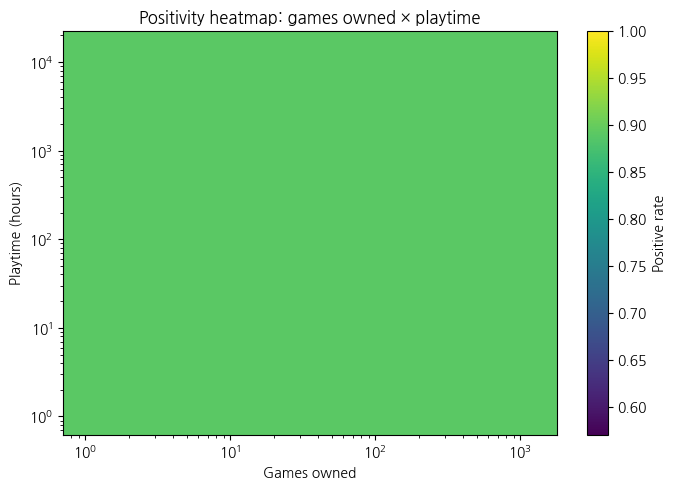

In [ ]:
# 산점도는 너무 크면 과밀 → 2D-bin(hexbins)로 "평균 긍정률" 색상표시가 안정적
sub_vis = dfu  # 필요 시 .sample(100000, random_state=0)
fig, ax = plt.subplots(figsize=(7,5))
hb = ax.hexbin(
    sub_vis['author_num_games_owned'].clip(lower=1),
    sub_vis['author_playtime_forever'].clip(lower=1),
    C=sub_vis['voted_up'],
    reduce_C_function=np.mean, gridsize=50, mincnt=30
)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Games owned')
ax.set_ylabel('Playtime (hours)')
cb = fig.colorbar(hb, ax=ax); cb.set_label('Positive rate')
ax.set_title('Positivity heatmap: games owned × playtime')
plt.tight_layout(); plt.show()


/tmp/ipython-input-4235293807.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (dfu.groupby(['cluster','pt_bin'])['voted_up']
/tmp/ipython-input-4235293807.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cl, gg in g.groupby('cluster'):


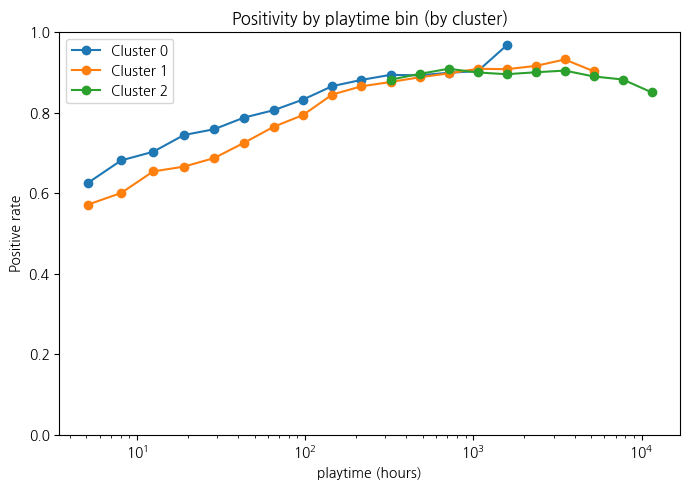

In [ ]:
# 로그-균등 구간
edges = np.unique(np.logspace(0, np.log10(dfu['author_playtime_forever'].max()+1), 25)-1)
dfu['pt_bin'] = pd.cut(dfu['author_playtime_forever'], bins=edges, include_lowest=True)

g = (dfu.groupby(['cluster','pt_bin'])['voted_up']
         .agg(PosRate='mean', N='size')
         .reset_index())
g = g[g['N']>=50]  # 표본 적은 구간 제거

fig, ax = plt.subplots(figsize=(7,5))
for cl, gg in g.groupby('cluster'):
    # bin 중앙값
    mid = gg['pt_bin'].apply(lambda x: x.mid)
    ax.plot(mid, gg['PosRate'], marker='o', label=f'Cluster {cl}')
ax.set_xscale('log'); ax.set_xlabel('playtime (hours)')
ax.set_ylabel('Positive rate')
ax.set_ylim(0,1)
ax.set_title('Positivity by playtime bin (by cluster)')
ax.legend(); plt.tight_layout(); plt.show()


##상위fps20개 한정으로 플레이어 시간과 리뷰분

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# ---------------------------
# 1) 유저 단위 집계 (재확인)
# ---------------------------
df_user = (df.groupby('author_steamid')
             .agg(
                 n_games=('appid','nunique'),
                 mean_pos=('voted_up','mean'),
                 total_reviews=('recommendationid','count'),
                 total_playtime=('author_playtime_forever','sum'),
                 steam_purchase=('steam_purchase','max'),
                 received_for_free=('received_for_free','max'),
                 early_access=('written_during_early_access','max')
             )
             .reset_index())

# ---------------------------
# 2) 플레이타임 기준 2개 그룹
#    기준선: 10000분(≈166시간)
# ---------------------------
df_user['gamer_type'] = pd.cut(
    df_user['total_playtime'],
    bins=[0, 10000, float('inf')],
    labels=['Light', 'Heavy'],
    right=False
)

# ---------------------------
# 3) 긍정률/규모 요약
# ---------------------------
posrate_table = (
    df_user.groupby('gamer_type', observed=True)
           .agg(PosRate=('mean_pos','mean'),
                Users=('author_steamid','count'),
                TotalReviews=('total_reviews','sum'),
                MedianPlaytimeMin=('total_playtime','median'),
                AvgGames=('n_games','mean'))
           .reset_index()
)

# ---------------------------
# 4) 구매/무료/EA 비율
# ---------------------------
rate_table = (
    df_user.groupby('gamer_type', observed=True)
           .agg(PurchaseRate=('steam_purchase','mean'),
                FreeRate=('received_for_free','mean'),
                EARate=('early_access','mean'))
           .reset_index()
)

# ---------------------------
# 5) 카이제곱 검정 (구매/무료/EA)
# ---------------------------
def chi2_for_binary(df_, type_col, bin_col):
    contingency = pd.crosstab(df_[type_col], df_[bin_col])
    chi2, p, dof, exp = chi2_contingency(contingency)
    return contingency, {'chi2': chi2, 'p': p, 'dof': dof}

cont_purchase, stat_purchase = chi2_for_binary(df_user, 'gamer_type', 'steam_purchase')
cont_free,     stat_free     = chi2_for_binary(df_user, 'gamer_type', 'received_for_free')
cont_ea,       stat_ea       = chi2_for_binary(df_user, 'gamer_type', 'early_access')

# ---------------------------
# 6) 결과 출력
# ---------------------------
print("[유형별 긍정률/규모]")
print(posrate_table.to_string(index=False))

print("\n[유형별 구매/무료/EA 비율]")
print(rate_table.to_string(index=False))

print("\n[카이제곱] gamer_type x steam_purchase")
print(cont_purchase)
print(stat_purchase)

print("\n[카이제곱] gamer_type x received_for_free")
print(cont_free)
print(stat_free)

print("\n[카이제곱] gamer_type x early_access")
print(cont_ea)
print(stat_ea)


[유형별 긍정률/규모]
gamer_type  PosRate  Users  TotalReviews  MedianPlaytimeMin  AvgGames
     Light 0.741956   5180          5277             1783.0  1.018726
     Heavy 0.810588   7395          7693            58679.0  1.040297

[유형별 구매/무료/EA 비율]
gamer_type  PurchaseRate  FreeRate   EARate
     Light      0.588224  0.043822 0.156178
     Heavy      0.593239  0.035970 0.064368

[카이제곱] gamer_type x steam_purchase
steam_purchase     0     1
gamer_type                
Light           2133  3047
Heavy           3008  4387
{'chi2': np.float64(0.2965489393666405), 'p': np.float64(0.5860540584491641), 'dof': 1}

[카이제곱] gamer_type x received_for_free
received_for_free     0    1
gamer_type                  
Light              4953  227
Heavy              7129  266
{'chi2': np.float64(4.77988590023593), 'p': np.float64(0.02879402849262985), 'dof': 1}

[카이제곱] gamer_type x early_access
early_access     0    1
gamer_type             
Light         4371  809
Heavy         6919  476
{'chi2': np.float64(27

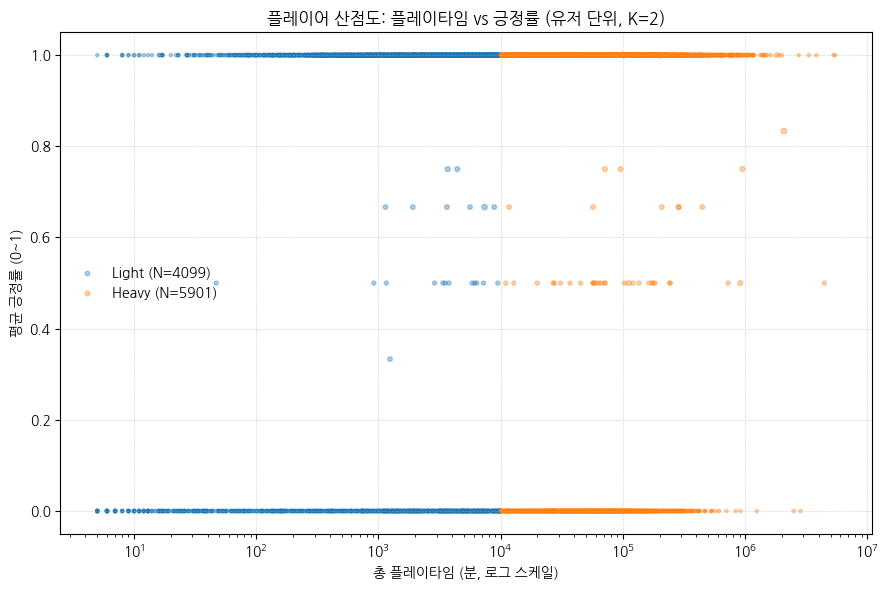

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) df_user 준비 (없으면 생성)
#    df: 원본 리뷰 데이터프레임 (행 = 리뷰 단위)
# ------------------------------------------------------------
if 'df_user' not in globals():
    df_user = (df.groupby('author_steamid')
                 .agg(
                     n_games=('appid','nunique'),                # 소유 게임 수
                     mean_pos=('voted_up','mean'),               # 평균 긍정률
                     total_reviews=('recommendationid','count'), # 작성 리뷰 수
                     total_playtime=('author_playtime_forever','sum'), # 총 플레이타임
                     steam_purchase=('steam_purchase','max'),    # 구매 여부
                     received_for_free=('received_for_free','max'), # 무료 수령 여부
                     early_access=('written_during_early_access','max') # 얼리억세스 여부
                 ).reset_index())

    # K=2 (라이트/헤비) 분류: 10000분(≈166시간) 기준
    df_user['gamer_type'] = pd.cut(
        df_user['total_playtime'],
        bins=[0, 10000, float('inf')],
        labels=['라이트', '헤비'],
        right=False
    )


# ------------------------------------------------------------
# 1) 그릴 데이터 전처리
#    - total_playtime > 0, mean_pos 유효한 데이터만
#    - 산점도 과밀 방지를 위해 최대 10,000명 샘플링
# ------------------------------------------------------------
plot_df = df_user.loc[(df_user['total_playtime'] > 0) & (df_user['mean_pos'].notna())].copy()

max_points = 10_000
if len(plot_df) > max_points:
    plot_df = plot_df.sample(n=max_points, random_state=42)

# 마커 크기: 리뷰 수를 로그 스케일로 변환 후 보정
# (너무 큰 값 방지: +1로 log 안정화, 배수로 크기 조절)
marker_size = np.log1p(plot_df['total_reviews']).values * 8.0

# ------------------------------------------------------------
# 2) 산점도 그리기 (유저 유형별)
#    - 색상은 기본 자동 할당
#    - x축 로그 스케일 적용
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

for gt in ['Light', 'Heavy']:
    sub = plot_df[plot_df['gamer_type'] == gt]
    if len(sub) == 0:
        continue
    plt.scatter(
        sub['total_playtime'],
        sub['mean_pos'],
        s=np.log1p(sub['total_reviews']).values * 8.0,
        alpha=0.35,
        label=f"{gt} (N={len(sub)})"
    )

plt.xscale('log')
plt.xlabel('총 플레이타임 (분, 로그 스케일)')
plt.ylabel('평균 긍정률 (0~1)')
plt.title('플레이어 산점도: 플레이타임 vs 긍정률 (유저 단위, K=2)')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


#####1) LOWESS 스무딩 추세선 (+가중 WLS 회귀선)

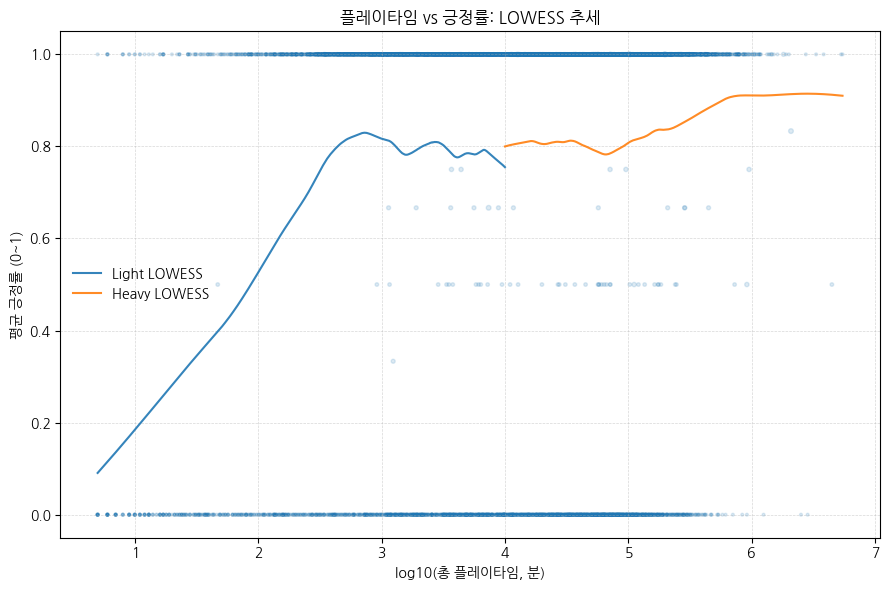

                            WLS Regression Results                            
Dep. Variable:               mean_pos   R-squared:                       0.035
Model:                            WLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     121.1
Date:                Thu, 18 Sep 2025   Prob (F-statistic):           4.65e-77
Time:                        06:23:32   Log-Likelihood:                -5006.0
No. Observations:               10000   AIC:                         1.002e+04
Df Residuals:                    9996   BIC:                         1.005e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2765      0.029      9.626      0.0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

# 준비
use = plot_df.dropna(subset=['total_playtime','mean_pos','total_reviews']).copy()
use = use[use['total_playtime'] > 0]
use['log_total_play'] = np.log10(use['total_playtime'])

# ---- 1A. LOWESS (비모수 스무딩) : 전체 + 집단별
plt.figure(figsize=(9,6))

for gt, color in [('Light','tab:blue'), ('Heavy','tab:orange')]:
    sub = use[use['gamer_type']==gt]
    if sub.empty:
        continue
    smoothed = lowess(sub['mean_pos'], sub['log_total_play'], frac=0.25, it=0, return_sorted=True)
    plt.plot(smoothed[:,0], smoothed[:,1], label=f'{gt} LOWESS', alpha=0.9)

# 산점도(희미하게)
plt.scatter(use['log_total_play'], use['mean_pos'], s=np.log1p(use['total_reviews'])*6, alpha=0.15)

plt.xlabel('log10(총 플레이타임, 분)')
plt.ylabel('평균 긍정률 (0~1)')
plt.title('플레이타임 vs 긍정률: LOWESS 추세')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# ---- 1B. 가중 최소제곱(WLS) 회귀: mean_pos ~ log_total_play (+집단 더미)
use['is_heavy'] = (use['gamer_type']=='Heavy').astype(int)
X = sm.add_constant(np.c_[use['log_total_play'], use['is_heavy'], use['log_total_play']*use['is_heavy']])
model = sm.WLS(use['mean_pos'], X, weights=np.clip(use['total_reviews'], 1, None)).fit()
print(model.summary())


#####구간화(빈) 평균/신뢰구간 에러바

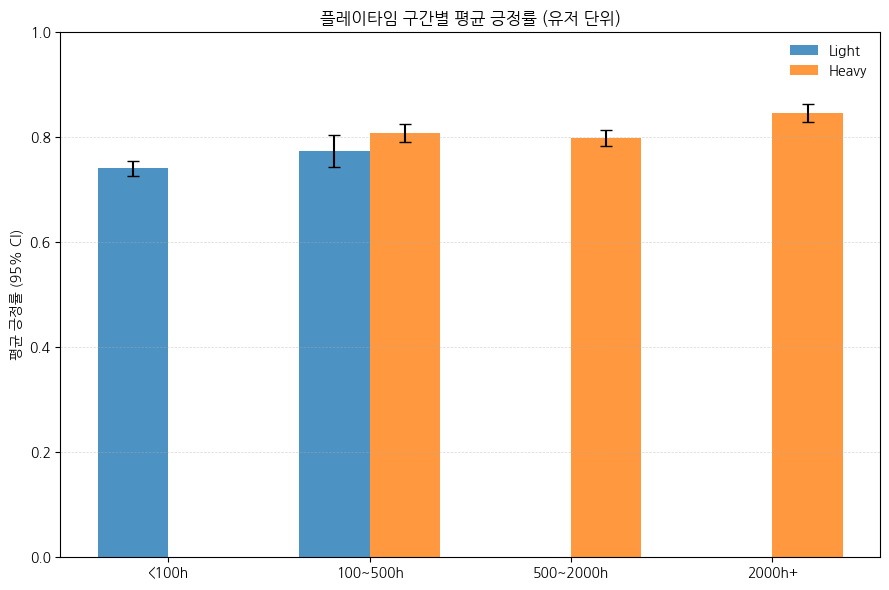

In [ ]:
import numpy as np

# 구간 정의(분 단위): <100h, 100~500h, 500~2000h, 2000h+
bins = [0, 6000, 30000, 120000, np.inf]  # 100h=6000분
labels = ['<100h','100~500h','500~2000h','2000h+']

bdf = use.copy()
bdf['bin'] = pd.cut(bdf['total_playtime'], bins=bins, labels=labels, right=False)

def boot_mean_ci(x, B=500, alpha=0.05):
    if len(x)==0:
        return np.nan, (np.nan, np.nan)
    boots = np.random.choice(x, size=(B, len(x)), replace=True).mean(axis=1)
    lo, hi = np.quantile(boots, [alpha/2, 1-alpha/2])
    return float(np.mean(x)), (float(lo), float(hi))

plot_stats = []
for gt in ['Light','Heavy']:
    subg = bdf[bdf['gamer_type']==gt]
    for lb in labels:
        vals = subg.loc[subg['bin']==lb, 'mean_pos'].dropna().values
        m, (lo, hi) = boot_mean_ci(vals)
        plot_stats.append({'group':gt,'bin':lb,'mean':m,'lo':lo,'hi':hi,'n':len(vals)})

plot_stats = pd.DataFrame(plot_stats)

# 시각화
plt.figure(figsize=(9,6))
xpos = np.arange(len(labels))
width = 0.35

for i, gt in enumerate(['Light','Heavy']):
    sub = plot_stats[plot_stats['group']==gt]
    plt.bar(xpos + (i-0.5)*width, sub['mean'], width, yerr=[sub['mean']-sub['lo'], sub['hi']-sub['mean']],
            alpha=0.8, label=f'{gt}', capsize=4)

plt.xticks(xpos, labels)
plt.ylim(0,1)
plt.ylabel('평균 긍정률 (95% CI)')
plt.title('플레이타임 구간별 평균 긍정률 (유저 단위)')
plt.legend(frameon=False)
plt.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


#####라이트 vs 헤비 통계검정 (효과크기 포함)

In [ ]:
from scipy import stats

light = use.loc[use['gamer_type']=='Light', 'mean_pos'].dropna().values
heavy = use.loc[use['gamer_type']=='Heavy', 'mean_pos'].dropna().values

# Mann-Whitney U (순위 검정)
u, p_u = stats.mannwhitneyu(light, heavy, alternative='two-sided')

# t-test (참고용)
t, p_t = stats.ttest_ind(light, heavy, equal_var=False)

# Cliff's delta (효과크기; -1~1, 0에 가까울수록 차이 작음)
def cliffs_delta(x, y):
    import itertools
    n = len(x); m = len(y)
    gt = sum(1 for a,b in itertools.product(x,y) if a > b)
    lt = sum(1 for a,b in itertools.product(x,y) if a < b)
    return (gt - lt) / (n*m)

cd = cliffs_delta(light, heavy)

print(f"[Mann-Whitney U] U={u:.0f}, p={p_u:.3g}")
print(f"[Welch t-test]  t={t:.3f}, p={p_t:.3g}")
print(f"[Cliff's delta] δ={cd:.3f}  (|δ|<0.147: 아주 작음, <0.33: 작음, <0.474: 중간, 그 이상: 큼)")
print(f"Light mean={light.mean():.3f}, Heavy mean={heavy.mean():.3f}, diff={heavy.mean()-light.mean():.3f}")


[Mann-Whitney U] U=11286039, p=1.72e-15
[Welch t-test]  t=-7.916, p=2.77e-15
[Cliff's delta] δ=-0.067  (|δ|<0.147: 아주 작음, <0.33: 작음, <0.474: 중간, 그 이상: 큼)
Light mean=0.746, Heavy mean=0.813, diff=0.067


In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# 로그 변환으로 스케일 보정 (게임 수, 리뷰 수, 플레이타임은 분포가 치우쳐 있음)
df_user['log_playtime'] = np.log1p(df_user['total_playtime'])
df_user['log_games'] = np.log1p(df_user['n_games'])
df_user['log_reviews'] = np.log1p(df_user['total_reviews'])

# 다변량 회귀식 (OLS)
fml = 'mean_pos ~ log_playtime + log_games + log_reviews + steam_purchase + received_for_free + early_access'
res = smf.ols(fml, data=df_user).fit(cov_type='HC3')  # 견고표준오차
print(res.summary())


                            OLS Regression Results                            
Dep. Variable:               mean_pos   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     103.1
Date:                Thu, 18 Sep 2025   Prob (F-statistic):          5.20e-107
Time:                        06:30:48   Log-Likelihood:                -6413.4
No. Observations:               12575   AIC:                         1.284e+04
Df Residuals:                   12569   BIC:                         1.288e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4274      0.02

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '


#설명력 추리

##공통: 로드 & 경량 전처리

In [ ]:
import pandas as pd, numpy as np
from pathlib import Path


# 기본 정리
df = df.dropna(subset=["voted_up","author_num_games_owned","author_num_reviews",
                       "author_playtime_forever","author_playtime_at_review","language"])
df["voted_up"] = df["voted_up"].astype(int)

# 극단치 윈저라이즈(상하 1% 컷) → 회귀/로짓 안정화
def winsorize(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi)

for col in ["author_num_games_owned","author_num_reviews",
            "author_playtime_forever","author_playtime_at_review",
            "votes_up","comment_count"]:
    df[col] = winsorize(df[col], 0.01)

# 로그 변환(0 보호)
for col in ["author_num_games_owned","author_num_reviews",
            "author_playtime_forever","author_playtime_at_review"]:
    df[f"log_{col}"] = np.log1p(df[col])

# 최근 2주 플레이가 분(=데이터 설명상 분)라고 하셨으므로, 분 그대로 사용
df["author_playtime_last_two_weeks"] = df["author_playtime_last_two_weeks"].fillna(0)
df["log_play2w"] = np.log1p(df["author_playtime_last_two_weeks"])


##파생변수(비율/강도/최근성) – 단일변수보다 설명력 ↑

In [ ]:
# (a) 초반 몰입도: 리뷰 시점/누적
df["engage_ratio"] = (df["author_playtime_at_review"] + 1) / (df["author_playtime_forever"] + 1)

# (b) 활동성: 리뷰 성향
df["review_intensity"] = (df["author_num_reviews"] + 1) / (df["author_num_games_owned"] + 1)

# (c) 최근성 강도: 최근2주 / 누적
df["recency_ratio"] = (df["author_playtime_last_two_weeks"] + 1) / (df["author_playtime_forever"] + 1)

# (d) 영향력 프록시: 공감/댓글 로그
df["log_votes_up"] = np.log1p(df["votes_up"])
df["log_comments"] = np.log1p(df["comment_count"])

# (e) 언어 상위만 더미(표본 크기 확보)
top_langs = df["language"].value_counts().head(8).index
for lg in top_langs:
    df[f"lang_{lg}"] = (df["language"]==lg).astype(int)


##상호작용: 단일 변수로 안 보이던 효과 드러내기

In [ ]:
df["int_purchase_play"] = df["steam_purchase"] * np.log1p(df["author_playtime_forever"])
df["int_free_owned"]    = df["received_for_free"] * np.log1p(df["author_num_games_owned"])
df["int_ea_recency"]    = df["written_during_early_access"] * df["recency_ratio"]


##층화(세분화) 비교: 집단 내에서 설명력 확인

In [ ]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

def safe_qcut(s: pd.Series, q=3, base_labels=("Low","Mid","High")):
    """
    - 분위수 경계를 얻되 duplicates='drop'으로 중복을 제거
    - 중복으로 실제 구간 수가 q보다 작아지면 라벨 길이도 자동 축소
    - 결과는 순서형 범주형으로 반환
    """
    # retbins=True로 실제 경계 확인
    _, bins = pd.qcut(s, q=q, retbins=True, duplicates='drop')
    n_bins = len(bins) - 1
    if n_bins < 1:
        # 전 구간이 같은 값인 극단 케이스: 전부 단일 구간으로 처리
        cat = pd.Series(pd.Categorical(["All"] * len(s), categories=["All"], ordered=True), index=s.index)
        return cat

    labels = list(base_labels)[:n_bins] if n_bins <= len(base_labels) else [f"Q{i+1}" for i in range(n_bins)]

    # 같은 경계를 그대로 cut에 사용 (라벨 수를 bins-1에 맞춤)
    band = pd.cut(s, bins=bins, include_lowest=True, labels=labels)

    # 순서형으로 명시
    band = band.astype(CategoricalDtype(categories=labels, ordered=True))
    return band

# 1) 안전한 3분할(중복 경계 자동 처리)
df["owned_band"] = safe_qcut(df["author_num_games_owned"], q=3, base_labels=("Low","Mid","High"))
df["play_band"]  = safe_qcut(df["author_playtime_forever"], q=3, base_labels=("Low","Mid","High"))

# 2) 결측(분할 실패 행) 제거 후 교차 요약
mask = df["owned_band"].notna() & df["play_band"].notna()
tab = (
    df.loc[mask]
      .groupby(["owned_band", "play_band", "steam_purchase"], observed=True)["voted_up"]
      .agg(PosRate="mean", N="size")
      .reset_index()
      .sort_values(["owned_band","play_band","steam_purchase"])
)

print(tab.head(15))


   owned_band play_band  steam_purchase   PosRate      N
0         Low       Low               0  0.782217  35269
1         Low       Low               1  0.792212  71029
2         Low       Mid               0  0.848718  25892
3         Low       Mid               1  0.879949  80849
4         Low      High               0  0.811121  35626
5         Low      High               1  0.863488  83817
6         Mid       Low               0  0.786373  21898
7         Mid       Low               1  0.805750  37951
8         Mid       Mid               0  0.876253  18651
9         Mid       Mid               1  0.898063  40525
10        Mid      High               0  0.878660  15609
11        Mid      High               1  0.906869  30978


##게임 효과 보정: 군집 상관(GEE) 또는 집단고정효과 대용

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

# -----------------------------
# 0) 유틸: robust z-score (median/MAD)
# -----------------------------
def rz(x):
    x = x.astype(float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return (x - med)  # 스케일 0이면 중심화만
    return (x - med) / (1.4826 * mad)

df = df.copy()

# 타겟/키 보정
if "voted_up" in df.columns:
    df["voted_up"] = (df["voted_up"] > 0).astype(int)
else:
    raise KeyError("voted_up 컬럼이 필요합니다.")
if "appid" not in df.columns:
    raise KeyError("appid 컬럼이 필요합니다.")

# -----------------------------
# 1) 로그 파생 (log1p)
# -----------------------------
for col_src, col_log in [
    ("author_playtime_forever", "log_author_playtime_forever"),
    ("author_num_games_owned",  "log_author_num_games_owned"),
    ("author_num_reviews",      "log_author_num_reviews"),
]:
    if col_src not in df.columns:
        raise KeyError(f"{col_src} 컬럼이 필요합니다.")
    df[col_log] = np.log1p(df[col_src].astype(float))

# 사용자가 예시로 언급한 파생 없으면 0으로 채워 행 소실 방지
for col in ["engage_ratio","review_intensity","recency_ratio"]:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = df[col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)

# 상호작용 생성 (없으면 만들기)
if "int_purchase_play" not in df.columns:
    df["int_purchase_play"] = df["steam_purchase"].astype(int) * df["log_author_playtime_forever"]
if "int_free_owned" not in df.columns:
    df["int_free_owned"]   = df["received_for_free"].astype(int) * df["log_author_num_games_owned"]
if "int_ea_recency" not in df.columns:
    df["int_ea_recency"]   = df["written_during_early_access"].astype(int) * df["recency_ratio"]

# -----------------------------
# 2) 언어 더미 (기준범주 drop)
# -----------------------------
lang_dum = pd.DataFrame(index=df.index)  # 기본값(없을 때 대비)
lang_terms = ""
if "language" in df.columns:
    top = df["language"].value_counts().head(8).index.tolist()
    df["language_top"] = df["language"].where(df["language"].isin(top), "other")
    lang_dum = pd.get_dummies(df["language_top"], prefix="lang", drop_first=True)
    # 중복 합치기에서 종종 같은 이름이 생길 수 있어 먼저 정리
    lang_dum = lang_dum.loc[:, ~lang_dum.columns.duplicated(keep="first")]
    df = pd.concat([df, lang_dum], axis=1)
    lang_terms = " + ".join(lang_dum.columns)

# -----------------------------
# 3) 피처 선택 & 전처리
# -----------------------------
feat = [
    "log_author_playtime_forever","log_author_num_games_owned","log_author_num_reviews",
    "engage_ratio","review_intensity","recency_ratio",
    "steam_purchase","received_for_free","written_during_early_access",
    "int_purchase_play","int_free_owned","int_ea_recency",
    "appid","voted_up"
]
if not lang_dum.empty:
    feat += lang_dum.columns.tolist()

X = df[feat].copy()

# 숫자형에 한해 유효성 필터(Inf/NaN)
num_cols = X.select_dtypes(include=[np.number]).columns
for c in num_cols:
    X[c] = X[c].replace([np.inf, -np.inf], np.nan)
is_finite = np.isfinite(X[num_cols]).all(axis=1)
X = X[is_finite].copy()

# (A) 중복 컬럼 제거 (첫 번째만 유지)
if X.columns.duplicated().any():
    dups = list(X.columns[X.columns.duplicated(keep=False)])
    print("[INFO] 중복 컬럼 제거:", dups)
    X = X.loc[:, ~X.columns.duplicated(keep="first")].copy()

# (B) 상수열 제거 — iloc로 Series 보장해 모호성 회피
const_like_cols = []
for j, c in enumerate(list(X.columns)):
    if c in ("appid","voted_up"):
        continue
    s = X.iloc[:, j]
    if s.nunique(dropna=True) <= 1:
        const_like_cols.append(c)
if const_like_cols:
    print("[INFO] 상수열 드랍:", const_like_cols)
    X = X.drop(columns=const_like_cols)

# (C) 표준화(연속형): robust z-score로 스케일 안정화
to_standardize = [
    "log_author_playtime_forever","log_author_num_games_owned","log_author_num_reviews",
    "engage_ratio","review_intensity","recency_ratio",
    "int_purchase_play","int_free_owned","int_ea_recency"
]
to_standardize = [c for c in to_standardize if c in X.columns]
for c in to_standardize:
    X[c] = rz(X[c]).clip(-8, 8)  # 극단값 클리핑으로 overflow 추가 방지

# -----------------------------
# 4) 포뮬러 구성
# -----------------------------
base_terms = [
    "log_author_playtime_forever","log_author_num_games_owned","log_author_num_reviews",
    "engage_ratio","review_intensity","recency_ratio",
    "steam_purchase","received_for_free","written_during_early_access",
    "int_purchase_play","int_free_owned","int_ea_recency"
]
base_terms = [t for t in base_terms if t in X.columns]
cat_terms = [c for c in X.columns if c.startswith("lang_")]
terms = base_terms + cat_terms
formula = "voted_up ~ " + " + ".join(terms) if terms else "voted_up ~ 1"

# -----------------------------
# 5) GEE (appid 클러스터)
# -----------------------------
groups = X["appid"]
gee_data = X.copy()
try:
    gee_model = GEE.from_formula(formula, groups=groups, data=gee_data,
                                 family=Binomial(), cov_struct=Exchangeable())
    gee_res = gee_model.fit(maxiter=200)
    print(gee_res.summary())
except Exception as e:
    print("[WARN] GEE 실패:", repr(e))

# -----------------------------
# 6) GLM(Logit) + 클러스터 로버스트 SE (McFadden R²)
# -----------------------------
try:
    glm_model = smf.glm(formula=formula, data=gee_data, family=sm.families.Binomial())
    glm_res = glm_model.fit(cov_type="cluster", cov_kwds={"groups": groups})
    ll_full = glm_res.llf
    ll_null = smf.glm("voted_up ~ 1", data=gee_data, family=sm.families.Binomial()).fit().llf
    mcfadden_r2 = 1 - ll_full/ll_null
    print(f"\n[GLM Clustered] McFadden R² = {mcfadden_r2:.4f}")
except np.linalg.LinAlgError as e:
    print("[WARN] GLM singular matrix (공선성/완전분리 가능):", repr(e))
    # 완전분리/공선성 대안: 규제 로지스틱
    try:
        exog = gee_data[terms]
        exog = sm.add_constant(exog, has_constant='add')
        logit_model = sm.Logit(gee_data["voted_up"], exog)
        logit_res = logit_model.fit_regularized(alpha=1.0, L1_wt=0.5, disp=False)
        print("[INFO] fit_regularized 성공. 계수 해석은 방향성과 중요도 위주로 보세요.")
    except Exception as e2:
        print("[ERROR] 정규화 로지스틱도 실패:", repr(e2))


[INFO] 중복 컬럼 제거: ['lang_english', 'lang_english', 'lang_english', 'lang_english', 'lang_japanese', 'lang_japanese', 'lang_japanese', 'lang_japanese', 'lang_koreana', 'lang_koreana', 'lang_koreana', 'lang_koreana', 'lang_other', 'lang_other', 'lang_other', 'lang_russian', 'lang_russian', 'lang_russian', 'lang_russian', 'lang_schinese', 'lang_schinese', 'lang_schinese', 'lang_schinese', 'lang_spanish', 'lang_spanish', 'lang_spanish', 'lang_spanish', 'lang_turkish', 'lang_turkish', 'lang_turkish', 'lang_turkish']
                               GEE Regression Results                              
Dep. Variable:                    voted_up   No. Observations:               498094
Model:                                 GEE   No. clusters:                    27315
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                3017
Family:                           Binomial   Mean cluster size: 

##5) 비선형/고차 상호작용 자동 탐색: 트리계열 + SHAP

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# 0) 모델이 학습한 피처 이름 확보 (DataFrame으로 학습했다면 존재)
feat_in = getattr(clf, "feature_names_in_", None)
if feat_in is None:
    # 혹시 numpy로 학습했다면, 현재 테스트 컬럼 사용
    feat_in = X_test.columns.to_numpy()

# 1) X_test 컬럼을 모델 학습 피처 순서로 정렬/정합 (누락은 0으로 채움)
X_test_aligned = X_test.reindex(columns=feat_in, fill_value=0)

# 2) 다운샘플로 속도 확보
n_keep = min(10_000, len(X_test_aligned))
Xti = X_test_aligned.sample(n=n_keep, random_state=42)
yti = y_test.loc[Xti.index]

# 3) permutation importance (빠른 설정)
r = permutation_importance(
    clf, Xti, yti,
    n_repeats=3,        # 필요시 5~10으로 올리면 안정성 ↑ (속도↓)
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

# 4) 길이 자동 일치: index는 Xti.columns 사용
imp = pd.Series(r.importances_mean, index=Xti.columns).sort_values(ascending=False)
imp_std = pd.Series(r.importances_std, index=Xti.columns).loc[imp.index]

print("Top 20 permutation importances (mean ± std):")
for f, m, s in zip(imp.index[:20], imp.values[:20], imp_std.values[:20]):
    print(f"{f:35s} {m: .6f} ± {s: .6f}")


Top 20 permutation importances (mean ± std):
log_votes_up                         0.071758 ±  0.000997
engage_ratio                         0.064717 ±  0.004048
log_author_num_games_owned           0.047909 ±  0.000300
review_intensity                     0.017783 ±  0.003446
log_author_num_reviews               0.017002 ±  0.002835
recency_ratio                        0.016133 ±  0.001725
int_purchase_play                    0.009325 ±  0.000213
log_comments                         0.009137 ±  0.001125
log_author_playtime_forever          0.008741 ±  0.000886
lang_english                         0.007390 ±  0.001051
lang_english                         0.007390 ±  0.001051
lang_english                         0.007390 ±  0.001051
lang_english                         0.007390 ±  0.001051
lang_english                         0.007390 ±  0.001051
lang_english                         0.007390 ±  0.001051
lang_english                         0.007390 ±  0.001051
lang_english               

##층화된 모형(교호 포함) – 라이트/미드/헤비 별로 따로 적합

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
from patsy import dmatrices

def _arraylike_cells(s: pd.Series) -> bool:
    return s.apply(lambda x: isinstance(x, (list, tuple, np.ndarray, pd.Series))).any()

def _strip_bad_terms(formula: str, df: pd.DataFrame, verbose=True):
    # formula에 등장 가능한 변수 후보 추출 (대략적)
    # 안전하게는 dmatrices를 try하고 실패 시 토큰 단위로 스캔
    tokens = [t.strip() for t in formula.replace('~','+').replace('*','+').replace(':','+').split('+')]
    # 함수/상수/수식(C(), np.log 등) 제거용 아주 러프한 필터
    vars_guess = [t for t in tokens if t and t.isidentifier() and t in df.columns]

    bad = [v for v in vars_guess if _arraylike_cells(df[v])]
    if bad and verbose:
        print(f"[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: {bad}")

    # 나쁜 변수는 우변에서 제거
    lhs, rhs = formula.split('~', 1)
    for v in bad:
        # 양끝 공백/플러스 정리
        rhs = rhs.replace(f'+ {v}', '').replace(f'{v} +', '').replace(v, '')
    rhs = '+'.join([t for t in [r.strip() for r in rhs.split('+')] if t])

    new_formula = f"{lhs.strip()} ~ {rhs}"
    return new_formula, bad

def fit_logit_by_band(df, formula, band_col="owned_band", drop_bad_terms=True):
    out = []
    # FutureWarning 억제/의도 명시
    for band, sub in df.groupby(band_col, observed=True):
        if sub["voted_up"].nunique() < 2:
            continue

        fml = formula
        if drop_bad_terms:
            fml, bad = _strip_bad_terms(fml, sub, verbose=True)

        # 디자인 행렬 사전 검증: 어디서 터지는지 즉시 알림
        try:
            dmatrices(fml, data=sub, return_type="dataframe")
        except Exception as e:
            raise RuntimeError(f"[{band_col}={band}] formula 빌드 실패: {e}\nformula={fml}")

        m = smf.glm(formula=fml, data=sub, family=sm.families.Binomial())
        r = m.fit(cov_type="cluster", cov_kwds={"groups": sub["appid"]})

        # Null 모델은 클러스터 옵션 없이 llf만 필요
        ll_full = r.llf
        ll_null = smf.glm("voted_up ~ 1", data=sub, family=sm.families.Binomial()).fit().llf
        mcf = 1 - ll_full/ll_null

        out.append((band, int(len(sub)), float(mcf)))

    return (
        pd.DataFrame(out, columns=[band_col, "N", "McFadden_R2"])
          .sort_values("McFadden_R2", ascending=False)
          .reset_index(drop=True)
    )

# 사용 예시
# formula = "voted_up ~ log_playtime + steam_purchase + received_for_free + written_during_early_access"
print(fit_logit_by_band(df, formula, "owned_band"))
print(fit_logit_by_band(df, formula, "play_band"))


[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
  owned_band       N  McFadden_R2
0        Low  332482     0.039907
1        Mid  165612     0.039219
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
  play_band       N  McFadden_R2
0      High  166030     0.041325
1       Low  166147     0.039572
2   

##7) 리포팅에 바로 쓸 핵심 표/그림

In [ ]:
# (선택) 밴드 순서 보장 - 보고서 정렬용
if "owned_band" in df.columns:
    df["owned_band"] = pd.Categorical(df["owned_band"], ["Low","Mid","High"], ordered=True)
if "play_band" in df.columns:
    df["play_band"] = pd.Categorical(df["play_band"], ["Low","Mid","High"], ordered=True)

# (a) 층화 교차표
cross = (
    df.groupby(
        ["owned_band", "play_band", "steam_purchase", "received_for_free", "written_during_early_access"],
        observed=True  # FutureWarning 방지
    )["voted_up"]
    .agg(PosRate="mean", N="size")
    .reset_index()
)

# (정렬: 밴드 우선 → 나머지 키)
cross = cross.sort_values(
    ["owned_band", "play_band", "steam_purchase", "received_for_free", "written_during_early_access"]
)
display(cross.head(20))

# (b) 중요도 상위 10
display(imp.head(10).to_frame("importance"))

# (c) 층화별 R²
# fit_logit_by_band(df, formula, band_col) 시그니처에 맞게 호출
display(fit_logit_by_band(df, formula, "owned_band"))
display(fit_logit_by_band(df, formula, "play_band"))


,owned_band,play_band,steam_purchase,received_for_free,written_during_early_access,PosRate,N
0,Low,Low,0,0,0,0.780428,29225
1,Low,Low,0,0,1,0.734583,2773
2,Low,Low,0,1,0,0.838026,3019
3,Low,Low,0,1,1,0.845238,252
4,Low,Low,1,0,0,0.791888,63144
5,Low,Low,1,0,1,0.785063,7016
6,Low,Low,1,1,0,0.867246,806
7,Low,Low,1,1,1,0.952381,63
8,Low,Mid,0,0,0,0.844313,21023
9,Low,Mid,0,0,1,0.838403,2630


,importance
log_votes_up,0.071758
engage_ratio,0.064717
log_author_num_games_owned,0.047909
review_intensity,0.017783
log_author_num_reviews,0.017002
recency_ratio,0.016133
int_purchase_play,0.009325
log_comments,0.009137
log_author_playtime_forever,0.008741
lang_english,0.007390


[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']


,owned_band,N,McFadden_R2
0,Low,332482,0.039907
1,Mid,165612,0.039219


[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']
[warn] 셀에 배열/리스트가 들어있는 컬럼 제외: ['lang_english', 'lang_japanese', 'lang_koreana', 'lang_other', 'lang_russian', 'lang_schinese', 'lang_spanish', 'lang_turkish']


,play_band,N,McFadden_R2
0,High,166030,0.041325
1,Low,166147,0.039572
2,Mid,165917,0.024160


--------------------------------------

#구매 여부(steam_purchase), 무료 여부(received_for_free) 두 집단(0/1) 간 긍정률 차이

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, rankdata

# -----------------------------
# 효과크기 계산 함수 (최적화)
# -----------------------------
def cramers_v(confusion_matrix):
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2/min(k-1, r-1))

def cliffs_delta_fast(x, y):
    # rank 기반 Cliff’s delta (O(n log n))
    nx, ny = len(x), len(y)
    ranks = rankdata(np.concatenate([x, y]))
    r1 = np.sum(ranks[:nx])
    delta = (2*r1 - nx*(nx+1)) / (nx*ny)
    return delta

# -----------------------------
# 카이제곱 / Fisher
# -----------------------------
def test_chi_fisher(df, col, target="voted_up"):
    table = pd.crosstab(df[col], df[target])
    print(f"\n== {col} vs {target} ==")
    print(table)

    chi2, p, dof, exp = chi2_contingency(table)
    print(f"[Chi-square] chi2={chi2:.4f}, p={p:.3e}, dof={dof}")
    print(f"Cramér's V = {cramers_v(table):.4f}")

    if table.min().min() < 5:  # 셀 카운트 작으면 Fisher
        oddsratio, p_fisher = fisher_exact(table.values)
        print(f"[Fisher’s exact] OR={oddsratio:.4f}, p={p_fisher:.3e}")

# -----------------------------
# Mann–Whitney U (샘플링 지원)
# -----------------------------
def test_mannwhitney(df, col, target="voted_up", sample_size=50000):
    x = df[df[col]==0][target].values
    y = df[df[col]==1][target].values

    # 너무 크면 샘플링
    if len(x) > sample_size:
        x = np.random.choice(x, sample_size, replace=False)
    if len(y) > sample_size:
        y = np.random.choice(y, sample_size, replace=False)

    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    print(f"\n[Mann–Whitney U] {col} vs {target}")
    print(f"U={stat:.4f}, p={p:.3e}")
    print(f"Cliff’s delta (approx) = {cliffs_delta_fast(x, y):.4f}")

# -----------------------------
# 실행 예시
# -----------------------------
for col in ["steam_purchase", "received_for_free"]:
    test_chi_fisher(df, col)
    test_mannwhitney(df, col)



== steam_purchase vs voted_up ==
voted_up            0       1
steam_purchase               
0               14870   81755
1               21955  170984
[Chi-square] chi2=932.3771, p=8.986e-205, dof=1
Cramér's V = 0.0567

[Mann–Whitney U] steam_purchase vs voted_up
U=1199300000.0000, p=6.203e-79
Cliff’s delta (approx) = 0.9594

== received_for_free vs voted_up ==
voted_up               0       1
received_for_free               
0                  35556  243044
1                   1269    9695
[Chi-square] chi2=13.3089, p=2.641e-04, dof=1
Cramér's V = 0.0068

[Mann–Whitney U] received_for_free vs voted_up
U=271409004.0000, p=4.703e-03
Cliff’s delta (approx) = 0.9902


###EA vs 정식 출시 후 같은 게임 내 EA 시기 vs 정식 시기 긍정률:

In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# 각 게임(appid)별로 EA와 Release 긍정률 집계
agg = df.groupby(["appid", "written_during_early_access"])["voted_up"].mean().reset_index()

# 피벗: EA=1, Release=0
pivot = agg.pivot(index="appid", columns="written_during_early_access", values="voted_up").dropna()
pivot.columns = ["Release", "EA"]  # 0=Release, 1=EA

# 대응표본 Wilcoxon test
stat, p = wilcoxon(pivot["EA"], pivot["Release"])
print(f"Wilcoxon signed-rank test: stat={stat:.4f}, p={p:.4e}")


Wilcoxon signed-rank test: stat=53917.5000, p=1.4379e-17


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

# EA 리뷰와 Release 리뷰 분리
ea = df.loc[df["written_during_early_access"]==1, "voted_up"]
release = df.loc[df["written_during_early_access"]==0, "voted_up"]

# 독립표본 Mann–Whitney U test
stat, p = mannwhitneyu(ea, release, alternative="two-sided")
print(f"Mann–Whitney U test: U={stat:.4f}, p={p:.4e}")


Mann–Whitney U test: U=4240142722.0000, p=2.4734e-07


In [ ]:
import numpy as np

ea = df.loc[df["written_during_early_access"]==1, "voted_up"]
release = df.loc[df["written_during_early_access"]==0, "voted_up"]

n1, n2 = len(ea), len(release)

# rank-biserial correlation (효과 크기)
r = 1 - (2*4240142722)/(n1*n2)
print(f"Rank-biserial correlation (r) = {r:.4f}")

# Cliff's delta
delta = (2*4240142722)/(n1*n2) - 1
print(f"Cliff's delta = {delta:.4f}")


Rank-biserial correlation (r) = 0.0100
Cliff's delta = -0.0100


--------------------------------------------------------------------------------

##"리뷰의 '골든 타임'은 존재할까? - 출시 초기 vs 안정기 리뷰 패턴 분석"

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import os, time, requests
from dateutil import parser as dparser

# =========================================================
# 0) 타임스탬프 단위 자동 판별 & 변환 (초/밀리초 혼재 대비)
# =========================================================
def _to_datetime_auto(s):
    s = pd.to_numeric(s, errors='coerce')
    # 값이 매우 크면 밀리초로 가정
    unit = 'ms' if pd.Series(s).quantile(0.95) > 1e12 else 's'
    return pd.to_datetime(s, unit=unit, errors='coerce', utc=True)

# 컬럼 이름 후보 (데이터셋에 맞춰 필요 시 추가)
ts_cols = ['timestamp_created', 'timestamp_updated', 'review_time', 'created_at']

found = None
for c in ts_cols:
    if c in df.columns:
        found = c
        break
if found is None:
    raise KeyError("리뷰 작성 시각 컬럼을 찾을 수 없습니다. 후보: " + ', '.join(ts_cols))

df = df.copy()
df['review_dt'] = _to_datetime_auto(df[found])

# =========================================================
# 1) 출시일 준비: 이미 있는 경우 사용, 없으면 API로 획득
# =========================================================
RELEASE_COL_CANDIDATES = ['release_date', 'released_at', 'app_release_date']
has_release = None
for c in RELEASE_COL_CANDIDATES:
    if c in df.columns:
        has_release = c
        break

def parse_steam_date(s: str):
    if not isinstance(s, str) or not s.strip():
        return pd.NaT
    try:
        dt = dparser.parse(s, dayfirst=False, fuzzy=True)
        return pd.to_datetime(dt, utc=True)
    except Exception:
        return pd.NaT

def fetch_release_date(appid: int, session: requests.Session = None, retry: int = 2, sleep_sec: float = 0.25):
    url = f"https://store.steampowered.com/api/appdetails?appids={appid}&filters=release_date&l=en"
    sess = session or requests.Session()
    for _ in range(retry + 1):
        try:
            r = sess.get(url, timeout=10)
            if r.status_code == 200:
                js = r.json()
                if str(appid) in js and js[str(appid)]['success']:
                    rd = js[str(appid)]['data'].get('release_date', {})
                    return parse_steam_date(rd.get('date', ''))
        except Exception:
            pass
        time.sleep(sleep_sec)
    return pd.NaT

# 캐시 파일 (반복 실행 시 API 호출 최소화)
cache_path = '/content/_steam_release_cache.csv'

def build_release_table_from_api(appids, cache_path=cache_path):
    # 기존 캐시 로드
    cache = pd.DataFrame(columns=['appid','release_date'])
    if os.path.exists(cache_path):
        cache = pd.read_csv(cache_path)
        cache['release_date'] = pd.to_datetime(cache['release_date'], errors='coerce', utc=True)

    known = set(cache['appid'].astype(int).tolist())
    targets = sorted(set(map(int, appids)) - known)

    new_rows = []
    with requests.Session() as sess:
        for i, appid in enumerate(targets, 1):
            dt = fetch_release_date(appid, session=sess)
            new_rows.append({'appid': appid, 'release_date': dt})
            if i % 200 == 0:
                print(f"[info] fetched {i}/{len(targets)}")
            time.sleep(0.15)  # rate-limit 완화

    if new_rows:
        add = pd.DataFrame(new_rows)
        cache = pd.concat([cache, add], ignore_index=True)
        cache.to_csv(cache_path, index=False)

    cache['appid'] = cache['appid'].astype(int)
    return cache

# appid 확인
if 'appid' not in df.columns:
    raise KeyError("'appid' 컬럼이 필요합니다.")

if has_release:
    # 이미 출시일이 있다면 그대로 사용
    df['release_date'] = pd.to_datetime(df[has_release], errors='coerce', utc=True)
    meta_release = df[['appid','release_date']].dropna().drop_duplicates('appid')
else:
    # API로 출시일 획득
    meta_release = build_release_table_from_api(df['appid'].unique(), cache_path=cache_path)

# =========================================================
# 2) 조인 & 경과일/구간(Label) 계산
# =========================================================
df = df.merge(meta_release[['appid','release_date']], on='appid', how='left')
df = df[df['release_date'].notna()].copy()

# 출시일 이전에 작성된 리뷰 제거
df['days_since_release'] = (df['review_dt'] - df['release_date']).dt.days
df = df[df['days_since_release'] >= 0].copy()

# 기본 3단계 구간 (요구안: 초기/안정기 필터도 함께 제공)
bins = [-0.1, 30, 179, np.inf]
labels = ['initial(≤30d)', 'transition(31–179d)', 'stable(≥180d)']
df['phase'] = pd.cut(df['days_since_release'], bins=bins, labels=labels)

# 초기/안정기 서브셋
df_initial = df[df['phase'] == 'initial(≤30d)'].copy()
df_stable  = df[df['phase'] == 'stable(≥180d)'].copy()

print("== Phase 분포 ==")
print(df['phase'].value_counts(dropna=False).to_string())
print("\n샘플 확인:")
print(df[['appid','review_dt','release_date','days_since_release','phase']].head(10))

# =========================================================
# 3) (선택) 게임별 최소 리뷰 수 필터로 표본 편향 완화
#    - 초기/안정기 모두에서 최소 n개 이상 리뷰가 있는 게임만 사용
# =========================================================
min_reviews_per_game = 20  # 필요 시 조정
cnt_init = df_initial.groupby('appid').size()
cnt_stab = df_stable.groupby('appid').size()
eligible_appids = set(cnt_init[cnt_init >= min_reviews_per_game].index) & set(cnt_stab[cnt_stab >= min_reviews_per_game].index)

df_initial_bal = df_initial[df_initial['appid'].isin(eligible_appids)].copy()
df_stable_bal  = df_stable[df_stable['appid'].isin(eligible_appids)].copy()

print(f"\n균형 샘플 앱 갯수: {len(eligible_appids)} (min_reviews_per_game={min_reviews_per_game})")
print(f"초기 리뷰 수(균형): {len(df_initial_bal):,} / 안정기 리뷰 수(균형): {len(df_stable_bal):,}")

# (선택) CSV로 저장
# df.to_csv('/content/reviews_with_phase.csv', index=False)
# df_initial.to_csv('/content/reviews_initial_raw.csv', index=False)
# df_stable.to_csv('/content/reviews_stable_raw.csv', index=False)
# df_initial_bal.to_csv('/content/reviews_initial_bal.csv', index=False)
# df_stable_bal.to_csv('/content/reviews_stable_bal.csv', index=False)


[info] fetched 200/18461
[info] fetched 400/18461
[info] fetched 600/18461
[info] fetched 800/18461
[info] fetched 1000/18461
[info] fetched 1200/18461
[info] fetched 1400/18461
[info] fetched 1600/18461
[info] fetched 1800/18461
[info] fetched 2000/18461
[info] fetched 2200/18461
[info] fetched 2400/18461
[info] fetched 2600/18461
[info] fetched 2800/18461
[info] fetched 3000/18461
[info] fetched 3200/18461
[info] fetched 3400/18461
[info] fetched 3600/18461
[info] fetched 3800/18461
[info] fetched 4000/18461
[info] fetched 4200/18461
[info] fetched 4400/18461
[info] fetched 4600/18461
[info] fetched 4800/18461
[info] fetched 5000/18461
[info] fetched 5200/18461
[info] fetched 5400/18461
[info] fetched 5600/18461
[info] fetched 5800/18461
[info] fetched 6000/18461
[info] fetched 6200/18461
[info] fetched 6400/18461
[info] fetched 6600/18461
[info] fetched 6800/18461
[info] fetched 7000/18461
[info] fetched 7200/18461
[info] fetched 7400/18461
[info] fetched 7600/18461
[info] fetched 7

/tmp/ipython-input-3789107302.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cache = pd.concat([cache, add], ignore_index=True)


== Phase 분포 ==
phase
stable(≥180d)          91334
initial(≤30d)          29103
transition(31–179d)    14352

샘플 확인:
   appid                 review_dt              release_date  \
0     10 2023-10-01 16:55:29+00:00 2000-11-01 00:00:00+00:00   
1     10 2023-09-30 17:46:28+00:00 2000-11-01 00:00:00+00:00   
2     10 2023-09-30 13:52:18+00:00 2000-11-01 00:00:00+00:00   
3     10 2023-09-30 10:17:46+00:00 2000-11-01 00:00:00+00:00   
4     10 2023-09-29 14:53:19+00:00 2000-11-01 00:00:00+00:00   
5     10 2023-09-29 07:31:49+00:00 2000-11-01 00:00:00+00:00   
6     10 2023-09-28 22:12:19+00:00 2000-11-01 00:00:00+00:00   
7     10 2023-09-28 17:07:26+00:00 2000-11-01 00:00:00+00:00   
8     10 2023-09-14 23:27:32+00:00 2000-11-01 00:00:00+00:00   
9     10 2023-09-13 21:27:03+00:00 2000-11-01 00:00:00+00:00   

   days_since_release          phase  
0                8369  stable(≥180d)  
1                8368  stable(≥180d)  
2                8368  stable(≥180d)  
3                8368  

In [ ]:
import pandas as pd

# 1) 리뷰 날짜의 최댓값 확인
max_date = df['review_dt'].max()
print("데이터셋 최신 리뷰일:", max_date)

# 2) 5년 전 기준일 계산
cutoff_date = max_date - pd.DateOffset(years=5)
print("5년 전 기준일:", cutoff_date)

# 3) 필터링: 5년 이내 데이터만
df_recent5y = df[df['review_dt'] >= cutoff_date].copy()

print("원본 리뷰 수:", len(df))
print("5년 이내 리뷰 수:", len(df_recent5y))
print(df_recent5y['review_dt'].min(), "→", df_recent5y['review_dt'].max())


데이터셋 최신 리뷰일: 2023-10-31 19:47:40+00:00
5년 전 기준일: 2018-10-31 19:47:40+00:00
원본 리뷰 수: 134789
5년 이내 리뷰 수: 104333
2018-10-31 19:57:20+00:00 → 2023-10-31 19:47:40+00:00


In [ ]:
# 5년 이내 데이터만 사용
df_recent5y = df[df['review_dt'] >= cutoff_date].copy()

# Phase 분포 재계산
print("== 5년 이내 Phase 분포 ==")
print(df_recent5y['phase'].value_counts())

# 초기/안정기 균형 샘플도 다시 만들려면:
df_initial_5y = df_recent5y[df_recent5y['phase'] == 'initial(≤30d)']
df_stable_5y  = df_recent5y[df_recent5y['phase'] == 'stable(≥180d)']


== 5년 이내 Phase 분포 ==
phase
stable(≥180d)          72004
initial(≤30d)          21779
transition(31–179d)    10550
Name: count, dtype: int64


#####리뷰100건이상
0리뷰 기준 1291게임
20리뷰기준 120게임
100건이상 10게임

In [ ]:
# 5년 이내 데이터만 유지
df_recent5y = df[df['review_dt'] >= cutoff_date].copy()

# 초기/안정기만 추출
df_initial_5y = df_recent5y[df_recent5y['phase'] == 'initial(≤30d)'].copy()
df_stable_5y  = df_recent5y[df_recent5y['phase'] == 'stable(≥180d)'].copy()

# --------------------------------------
# 균형 조건: 각 게임(appid)별 최소 리뷰 수
# --------------------------------------
min_reviews_per_game = 100  # 조건 조정 가능

cnt_init = df_initial_5y.groupby('appid').size()
cnt_stab = df_stable_5y.groupby('appid').size()

# 두 조건을 모두 만족하는 게임(appid)만 사용
eligible_appids = set(cnt_init[cnt_init >= min_reviews_per_game].index) & \
                  set(cnt_stab[cnt_stab >= min_reviews_per_game].index)

# 필터 적용
df_initial_bal_5y = df_initial_5y[df_initial_5y['appid'].isin(eligible_appids)].copy()
df_stable_bal_5y  = df_stable_5y[df_stable_5y['appid'].isin(eligible_appids)].copy()

print("균형 샘플 앱 갯수:", len(eligible_appids))
print("초기 리뷰 수(균형):", len(df_initial_bal_5y))
print("안정기 리뷰 수(균형):", len(df_stable_bal_5y))


균형 샘플 앱 갯수: 10
초기 리뷰 수(균형): 1461
안정기 리뷰 수(균형): 3277


###Mann–Whitney U 테스트 + 시각화

✅ 균형 조건 적용 결과
- 분석 대상 게임 수: 10
- 초기 리뷰 수: 1461
- 안정기 리뷰 수: 3277

📊 지표: votes_up
- Mann–Whitney U 통계량 = 2868518.0
- p값 = 9.630e-28
- 초기 평균 = 648.67
- 안정기 평균 = 340.70


/tmp/ipython-input-168268048.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([a, b], labels=['초기(≤30일)', '안정기(≥180일)'], showmeans=True)


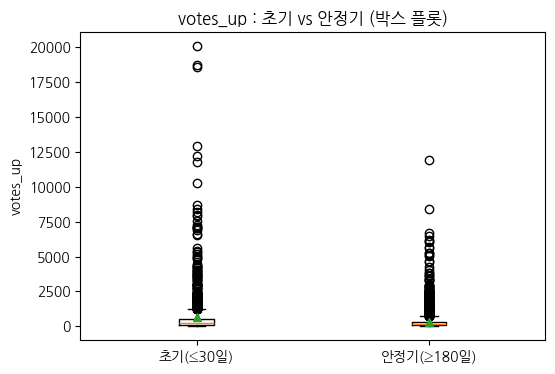

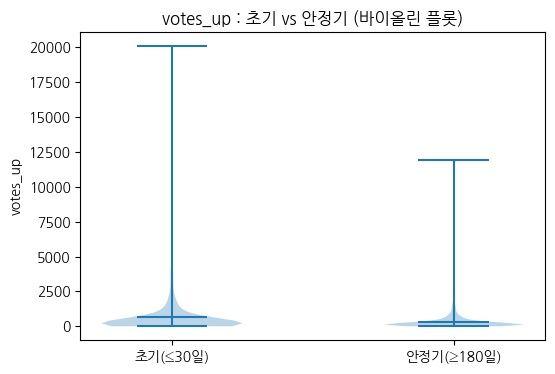


📊 지표: votes_funny
- Mann–Whitney U 통계량 = 2638660.0
- p값 = 1.795e-08
- 초기 평균 = 270.85
- 안정기 평균 = 118.78


/tmp/ipython-input-168268048.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([a, b], labels=['초기(≤30일)', '안정기(≥180일)'], showmeans=True)


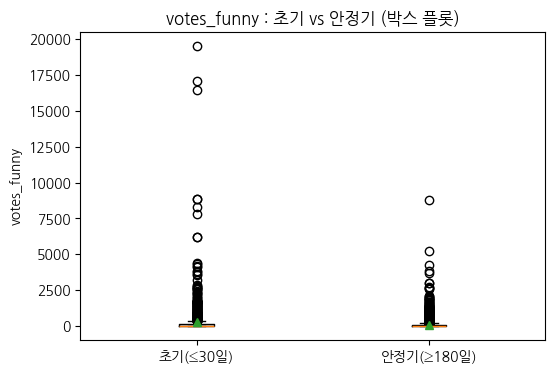

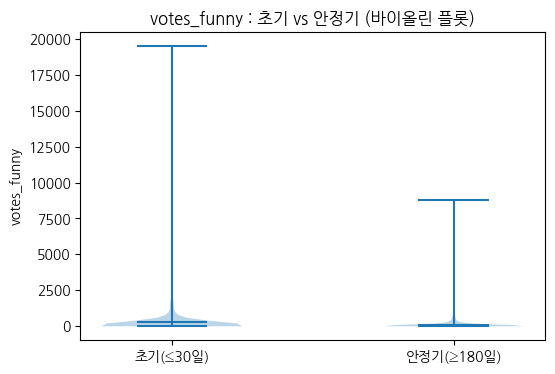


📊 지표: comment_count
- Mann–Whitney U 통계량 = 3093043.0
- p값 = 6.714e-72
- 초기 평균 = 13.97
- 안정기 평균 = 3.30


/tmp/ipython-input-168268048.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([a, b], labels=['초기(≤30일)', '안정기(≥180일)'], showmeans=True)


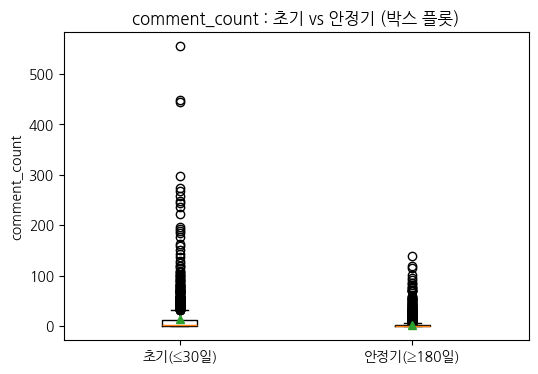

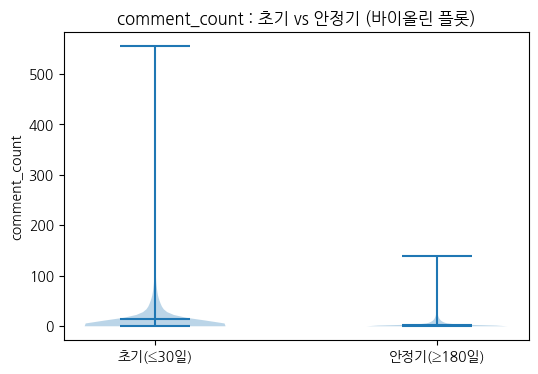

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --------------------------------------------
# 1. 균형 조건 필터 (100개 이상 리뷰)
# --------------------------------------------
min_reviews_per_game = 100
cnt_init = df_initial_5y.groupby('appid').size()
cnt_stab = df_stable_5y.groupby('appid').size()
eligible_appids = set(cnt_init[cnt_init >= min_reviews_per_game].index) & \
                  set(cnt_stab[cnt_stab >= min_reviews_per_game].index)

df_initial_bal_5y = df_initial_5y[df_initial_5y['appid'].isin(eligible_appids)].copy()
df_stable_bal_5y  = df_stable_5y[df_stable_5y['appid'].isin(eligible_appids)].copy()

print("✅ 균형 조건 적용 결과")
print(f"- 분석 대상 게임 수: {len(eligible_appids)}")
print(f"- 초기 리뷰 수: {len(df_initial_bal_5y)}")
print(f"- 안정기 리뷰 수: {len(df_stable_bal_5y)}")

# --------------------------------------------
# 2. 분석할 지표 리스트
# --------------------------------------------
metrics = ['votes_up', 'votes_funny', 'comment_count']  # 데이터셋에 있는 컬럼만 선택

for metric in metrics:
    if metric not in df_initial_bal_5y.columns:
        print(f"[건너뜀] {metric} 컬럼 없음")
        continue

    a = df_initial_bal_5y[metric].dropna()
    b = df_stable_bal_5y[metric].dropna()

    # Mann–Whitney U 검정
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    print(f"\n📊 지표: {metric}")
    print(f"- Mann–Whitney U 통계량 = {stat:.1f}")
    print(f"- p값 = {p:.3e}")
    print(f"- 초기 평균 = {a.mean():.2f}")
    print(f"- 안정기 평균 = {b.mean():.2f}")

    # ----------------------------------------
    # Box Plot (박스 플롯)
    # ----------------------------------------
    plt.figure(figsize=(6,4))
    plt.boxplot([a, b], labels=['초기(≤30일)', '안정기(≥180일)'], showmeans=True)
    plt.title(f'{metric} : 초기 vs 안정기 (박스 플롯)')
    plt.ylabel(metric)
    plt.show()

    # ----------------------------------------
    # Violin Plot (바이올린 플롯)
    # ----------------------------------------
    plt.figure(figsize=(6,4))
    plt.violinplot([a, b], showmeans=True)
    plt.xticks([1,2], ['초기(≤30일)', '안정기(≥180일)'])
    plt.title(f'{metric} : 초기 vs 안정기 (바이올린 플롯)')
    plt.ylabel(metric)
    plt.show()


In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

def effect_size_only(a, b):
    """
    효과 크기 계산 전용
    - 순위-비세리얼 상관계수 (r_b)
    - Cliff's delta
    """
    a = np.array(a.dropna())
    b = np.array(b.dropna())
    n1, n2 = len(a), len(b)

    U, _ = mannwhitneyu(a, b, alternative='two-sided')

    # Rank-biserial correlation
    r_b = 1 - (2*U) / (n1*n2)

    # Cliff's delta
    delta = (2*U) / (n1*n2) - 1

    return r_b, delta

# ----------------------------------------
# 주요 지표별 효과 크기 계산
# ----------------------------------------
metrics = ['votes_up', 'votes_funny', 'comment_count']

for metric in metrics:
    if metric not in df_initial_bal_5y.columns:
        continue

    a = df_initial_bal_5y[metric]
    b = df_stable_bal_5y[metric]

    r_b, delta = effect_size_only(a, b)

    print(f"\n📊 지표: {metric}")
    print(f"- 순위-비세리얼 상관계수 r_b = {r_b:.3f}")
    print(f"- Cliff's delta = {delta:.3f}")



📊 지표: votes_up
- 순위-비세리얼 상관계수 r_b = -0.198
- Cliff's delta = 0.198

📊 지표: votes_funny
- 순위-비세리얼 상관계수 r_b = -0.102
- Cliff's delta = 0.102

📊 지표: comment_count
- 순위-비세리얼 상관계수 r_b = -0.292
- Cliff's delta = 0.292
